# ABSA 전체 EDA: 다이소 뷰티 리뷰 Aspect 기반 감성 분석 (Stage 3A-v2, 323K)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# 시각화 기본 설정
plt.rcParams['figure.dpi'] = 300
sns.set_palette('Set2')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Noto Sans KR'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 이미지 저장 경로 (Why-pi/04_outputs/figures/EDA_ABSA_300k)
SAVE_FIGURES = True
FIG_DIR = '../../../04_outputs/figures/EDA_ABSA_300k'
if SAVE_FIGURES:
    os.makedirs(FIG_DIR, exist_ok=True)

print(f"폰트 설정: {plt.rcParams['font.family']}")
print(f"저장 경로: {os.path.abspath(FIG_DIR)}")

폰트 설정: ['Noto Sans KR']
저장 경로: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/04_outputs/figures/EDA_ABSA_300k


In [2]:
# 운영 스냅샷 데이터 로드 (Stage 3A-v2)
SNAPSHOT_DIR = '../04_outputs/snapshot/stage3a_v2_20260225'

df_review = pd.read_csv(f'{SNAPSHOT_DIR}/review_level.csv')
df_aspect = pd.read_csv(f'{SNAPSHOT_DIR}/aspect_long.csv')

# aspect_long에 리뷰 메타 조인
meta_cols = ['review_id', 'product_code', 'product_name', 'brand_name',
             'price', 'category_1', 'category_2', 'rating', 'review_date',
             'sentiment', 'sentiment_score', 'is_uncategorized']
df = df_aspect.merge(df_review[meta_cols], on='review_id', how='left')

print(f"review_level: {len(df_review):,}행 ({len(df_review.columns)}컬럼)")
print(f"aspect_long:  {len(df_aspect):,}행 ({len(df_aspect.columns)}컬럼)")
print(f"조인 후:      {len(df):,}행")
print(f"\nDtypes (aspect + meta):")
print(df.dtypes)
print(f"\n결측치:")
missing = df.isnull().sum()
print(missing[missing > 0])

review_level: 323,114행 (18컬럼)
aspect_long:  382,119행 (4컬럼)
조인 후:      382,119행

Dtypes (aspect + meta):
review_id             int64
aspect                  str
aspect_sentiment        str
is_ambiguous           bool
product_code          int64
product_name            str
brand_name              str
price               float64
category_1              str
category_2              str
rating              float64
review_date             str
sentiment               str
sentiment_score     float64
is_uncategorized       bool
dtype: object

결측치:
Series([], dtype: int64)


## 2. 데이터 개요

In [3]:
n_reviews = df_review['review_id'].nunique()
n_products = df_review['product_code'].nunique()
avg_aspects = df_aspect.groupby('review_id')['aspect'].count().mean()

print(f"고유 리뷰 수: {n_reviews:,}")
print(f"고유 상품 수: {n_products:,}")
print(f"리뷰당 평균 Aspect 수: {avg_aspects:.2f}")
print(f"전체 행 수 (리뷰×Aspect): {len(df):,}")

date_series = pd.to_datetime(df_review['review_date'], errors='coerce')
valid_dates = date_series.dropna()
print(f"리뷰 기간: {valid_dates.min().strftime('%Y-%m-%d')} ~ {valid_dates.max().strftime('%Y-%m-%d')}")

# 전체 감성 분포
print(f"\n전체 리뷰 감성 분포:")
for s in ['positive', 'neutral', 'negative']:
    cnt = (df_review['sentiment'] == s).sum()
    print(f"  {s}: {cnt:,} ({cnt/n_reviews*100:.1f}%)")

print(f"\nAmbiguous 리뷰: {df_review['is_ambiguous'].sum():,} ({df_review['is_ambiguous'].mean()*100:.1f}%)")
print(f"미분류 리뷰: {df_review['is_uncategorized'].sum():,} ({df_review['is_uncategorized'].mean()*100:.1f}%)")

고유 리뷰 수: 323,114
고유 상품 수: 937
리뷰당 평균 Aspect 수: 1.18
전체 행 수 (리뷰×Aspect): 382,119
리뷰 기간: 2024-01-01 ~ 2026-02-10

전체 리뷰 감성 분포:
  positive: 214,775 (66.5%)


  neutral: 94,023 (29.1%)
  negative: 14,316 (4.4%)

Ambiguous 리뷰: 16,305 (5.0%)
미분류 리뷰: 0 (0.0%)


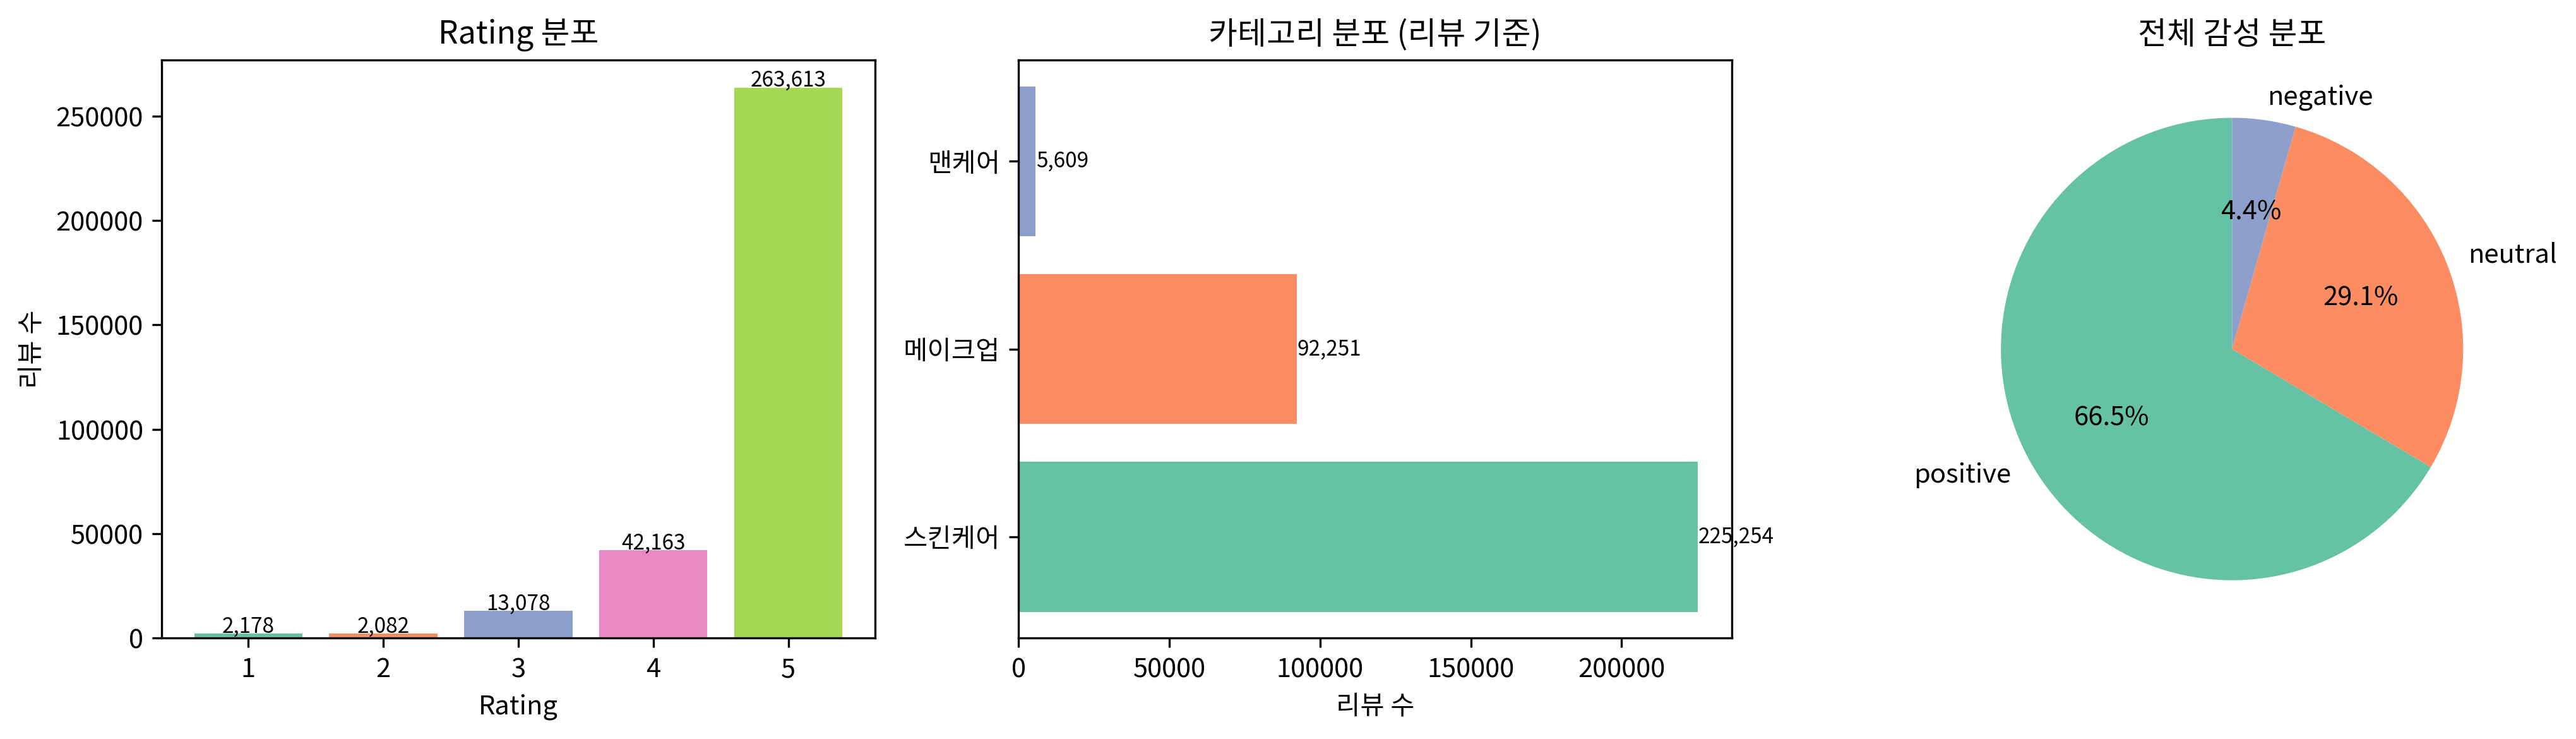

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# rating 분포
rating_counts = df_review['rating'].dropna().astype(int).value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Rating 분포')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('리뷰 수')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 500, f'{v:,}', ha='center', fontsize=8)

# category_1 분포
cat_counts = df_review['category_1'].dropna().value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color=sns.color_palette('Set2'))
axes[1].set_title('카테고리 분포 (리뷰 기준)')
axes[1].set_xlabel('리뷰 수')
for i, v in enumerate(cat_counts.values):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=8)

# 전체 감성 비율
sent_counts = df_review['sentiment'].value_counts()
colors_sent = {'positive': '#66c2a5', 'neutral': '#fc8d62', 'negative': '#8da0cb'}
axes[2].pie(sent_counts.values,
            labels=sent_counts.index,
            autopct='%1.1f%%',
            colors=[colors_sent.get(s, '#999') for s in sent_counts.index],
            startangle=90)
axes[2].set_title('전체 감성 분포')

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/01_데이터개요_Rating_카테고리_감성.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Aspect별 분포 분석

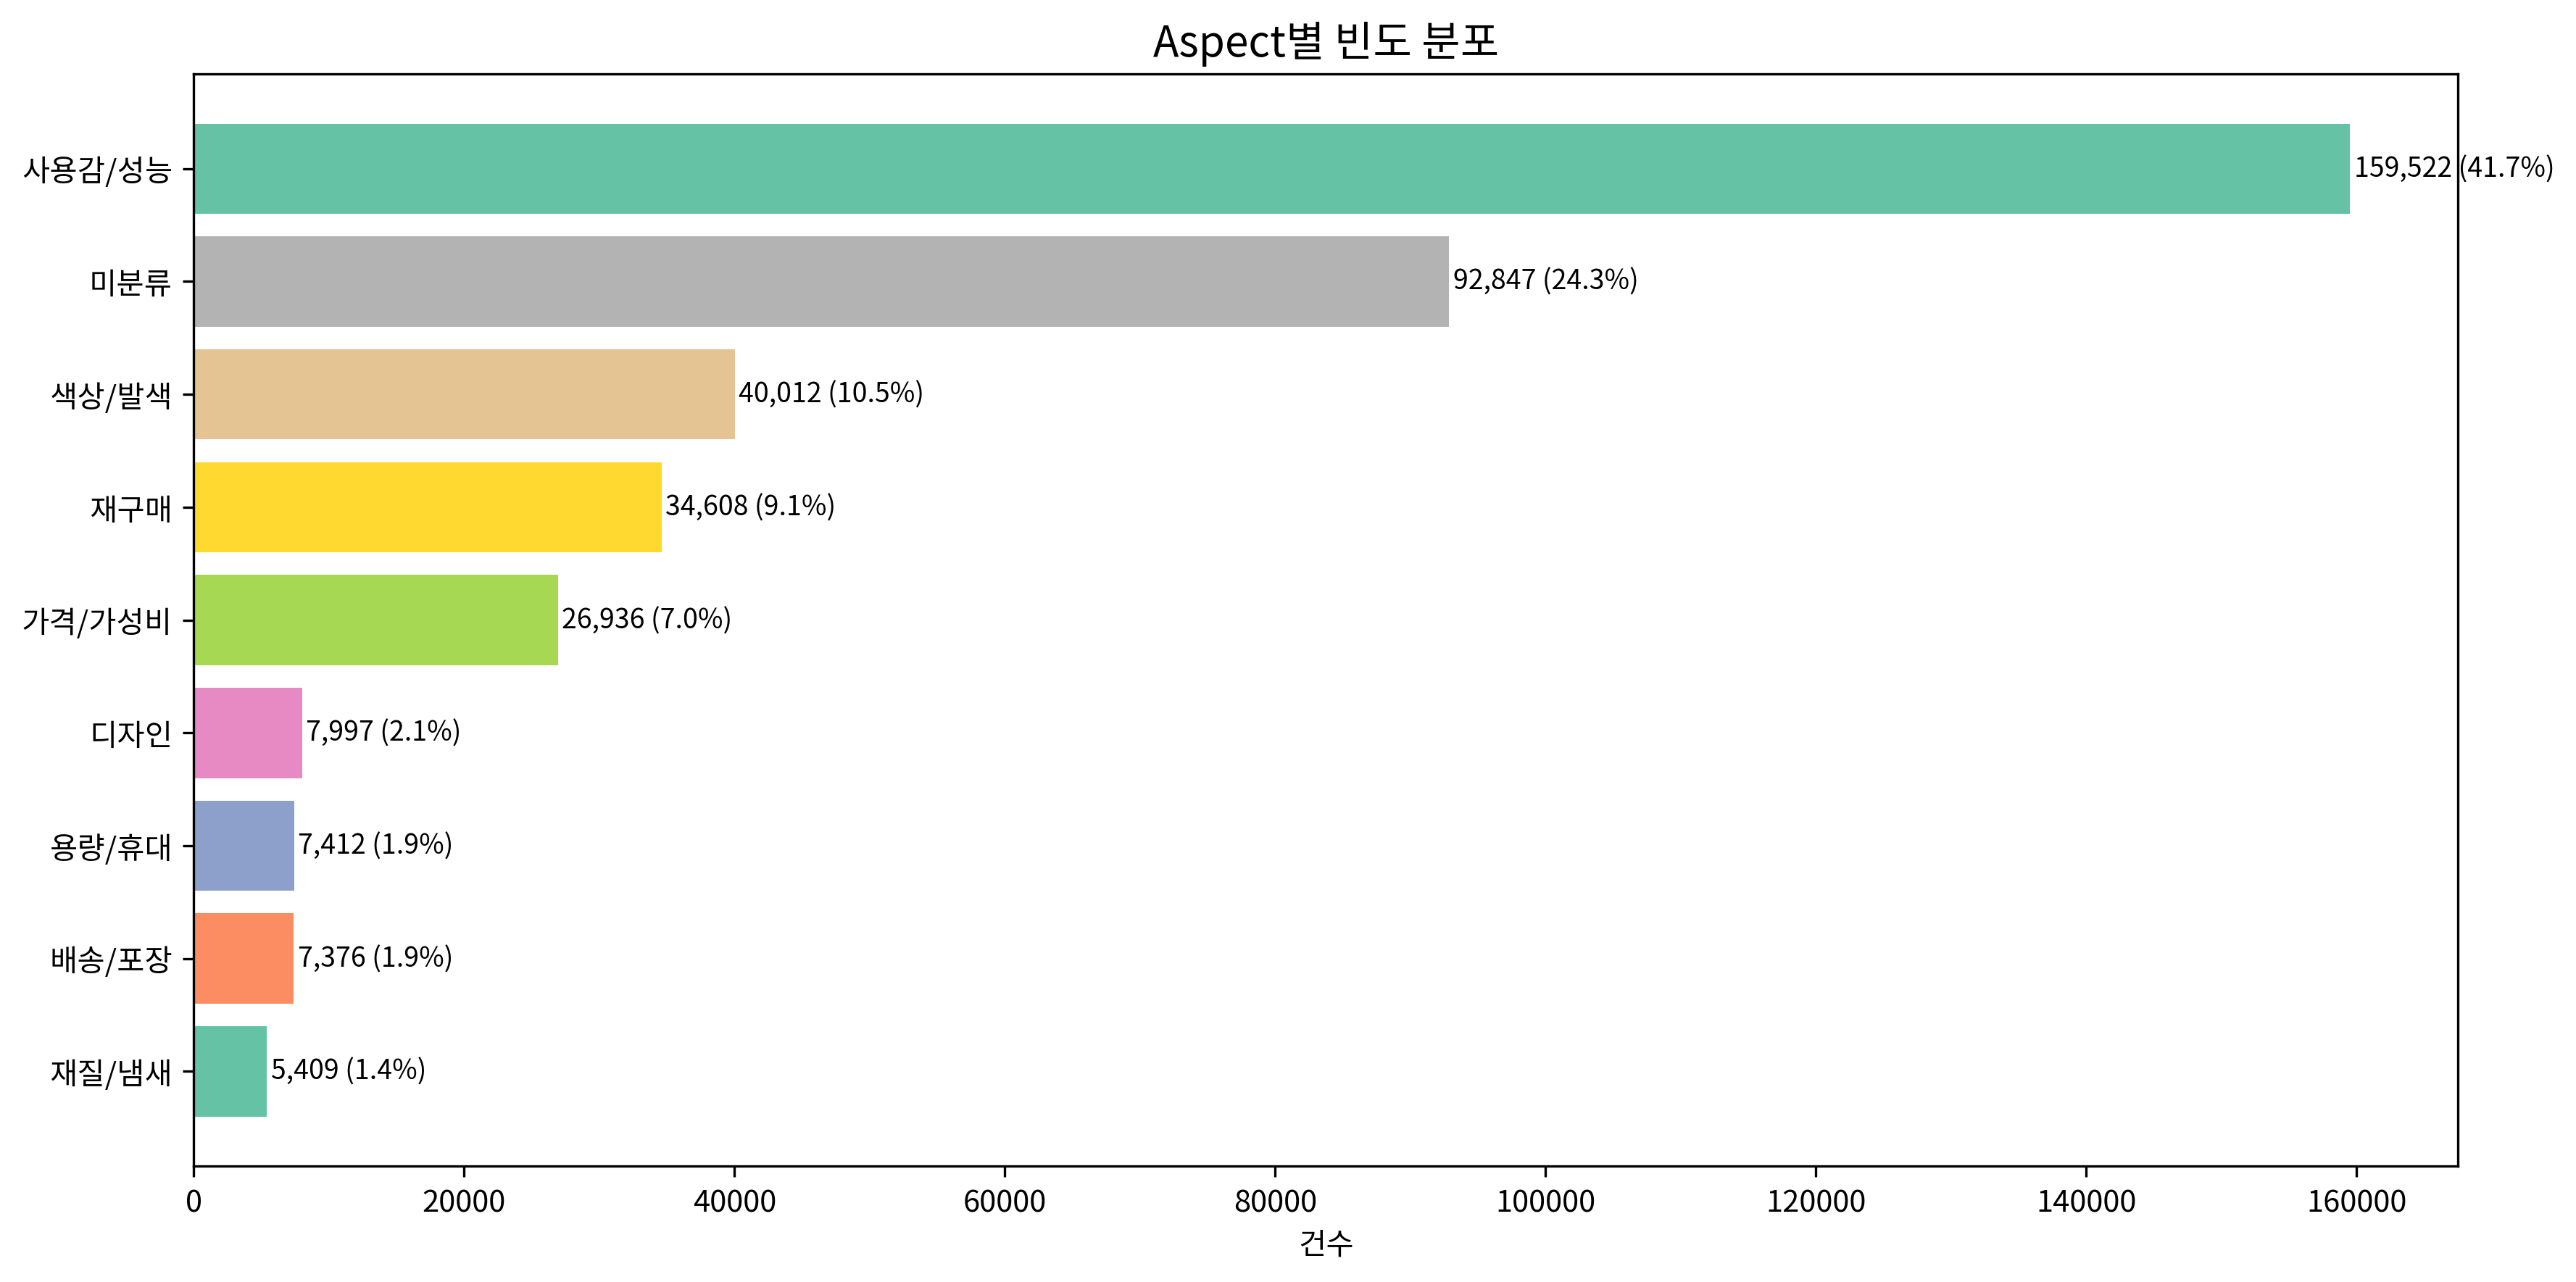


미분류 리뷰 비율: 0건 (0.0%)


In [5]:
aspect_counts = df['aspect'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(aspect_counts.index[::-1], aspect_counts.values[::-1],
               color=sns.color_palette('Set2', len(aspect_counts)))
ax.set_title('Aspect별 빈도 분포', fontsize=14)
ax.set_xlabel('건수')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 300, bar.get_y() + bar.get_height()/2,
            f'{int(width):,} ({width/len(df)*100:.1f}%)',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/02_Aspect별_빈도분포.png', dpi=300, bbox_inches='tight')
plt.show()

# 미분류 비율 (리뷰 단위)
print(f"\n미분류 리뷰 비율: {df_review['is_uncategorized'].sum():,}건 "
      f"({df_review['is_uncategorized'].mean()*100:.1f}%)")

## 4. Aspect × Sentiment 크로스 분석 (핵심)

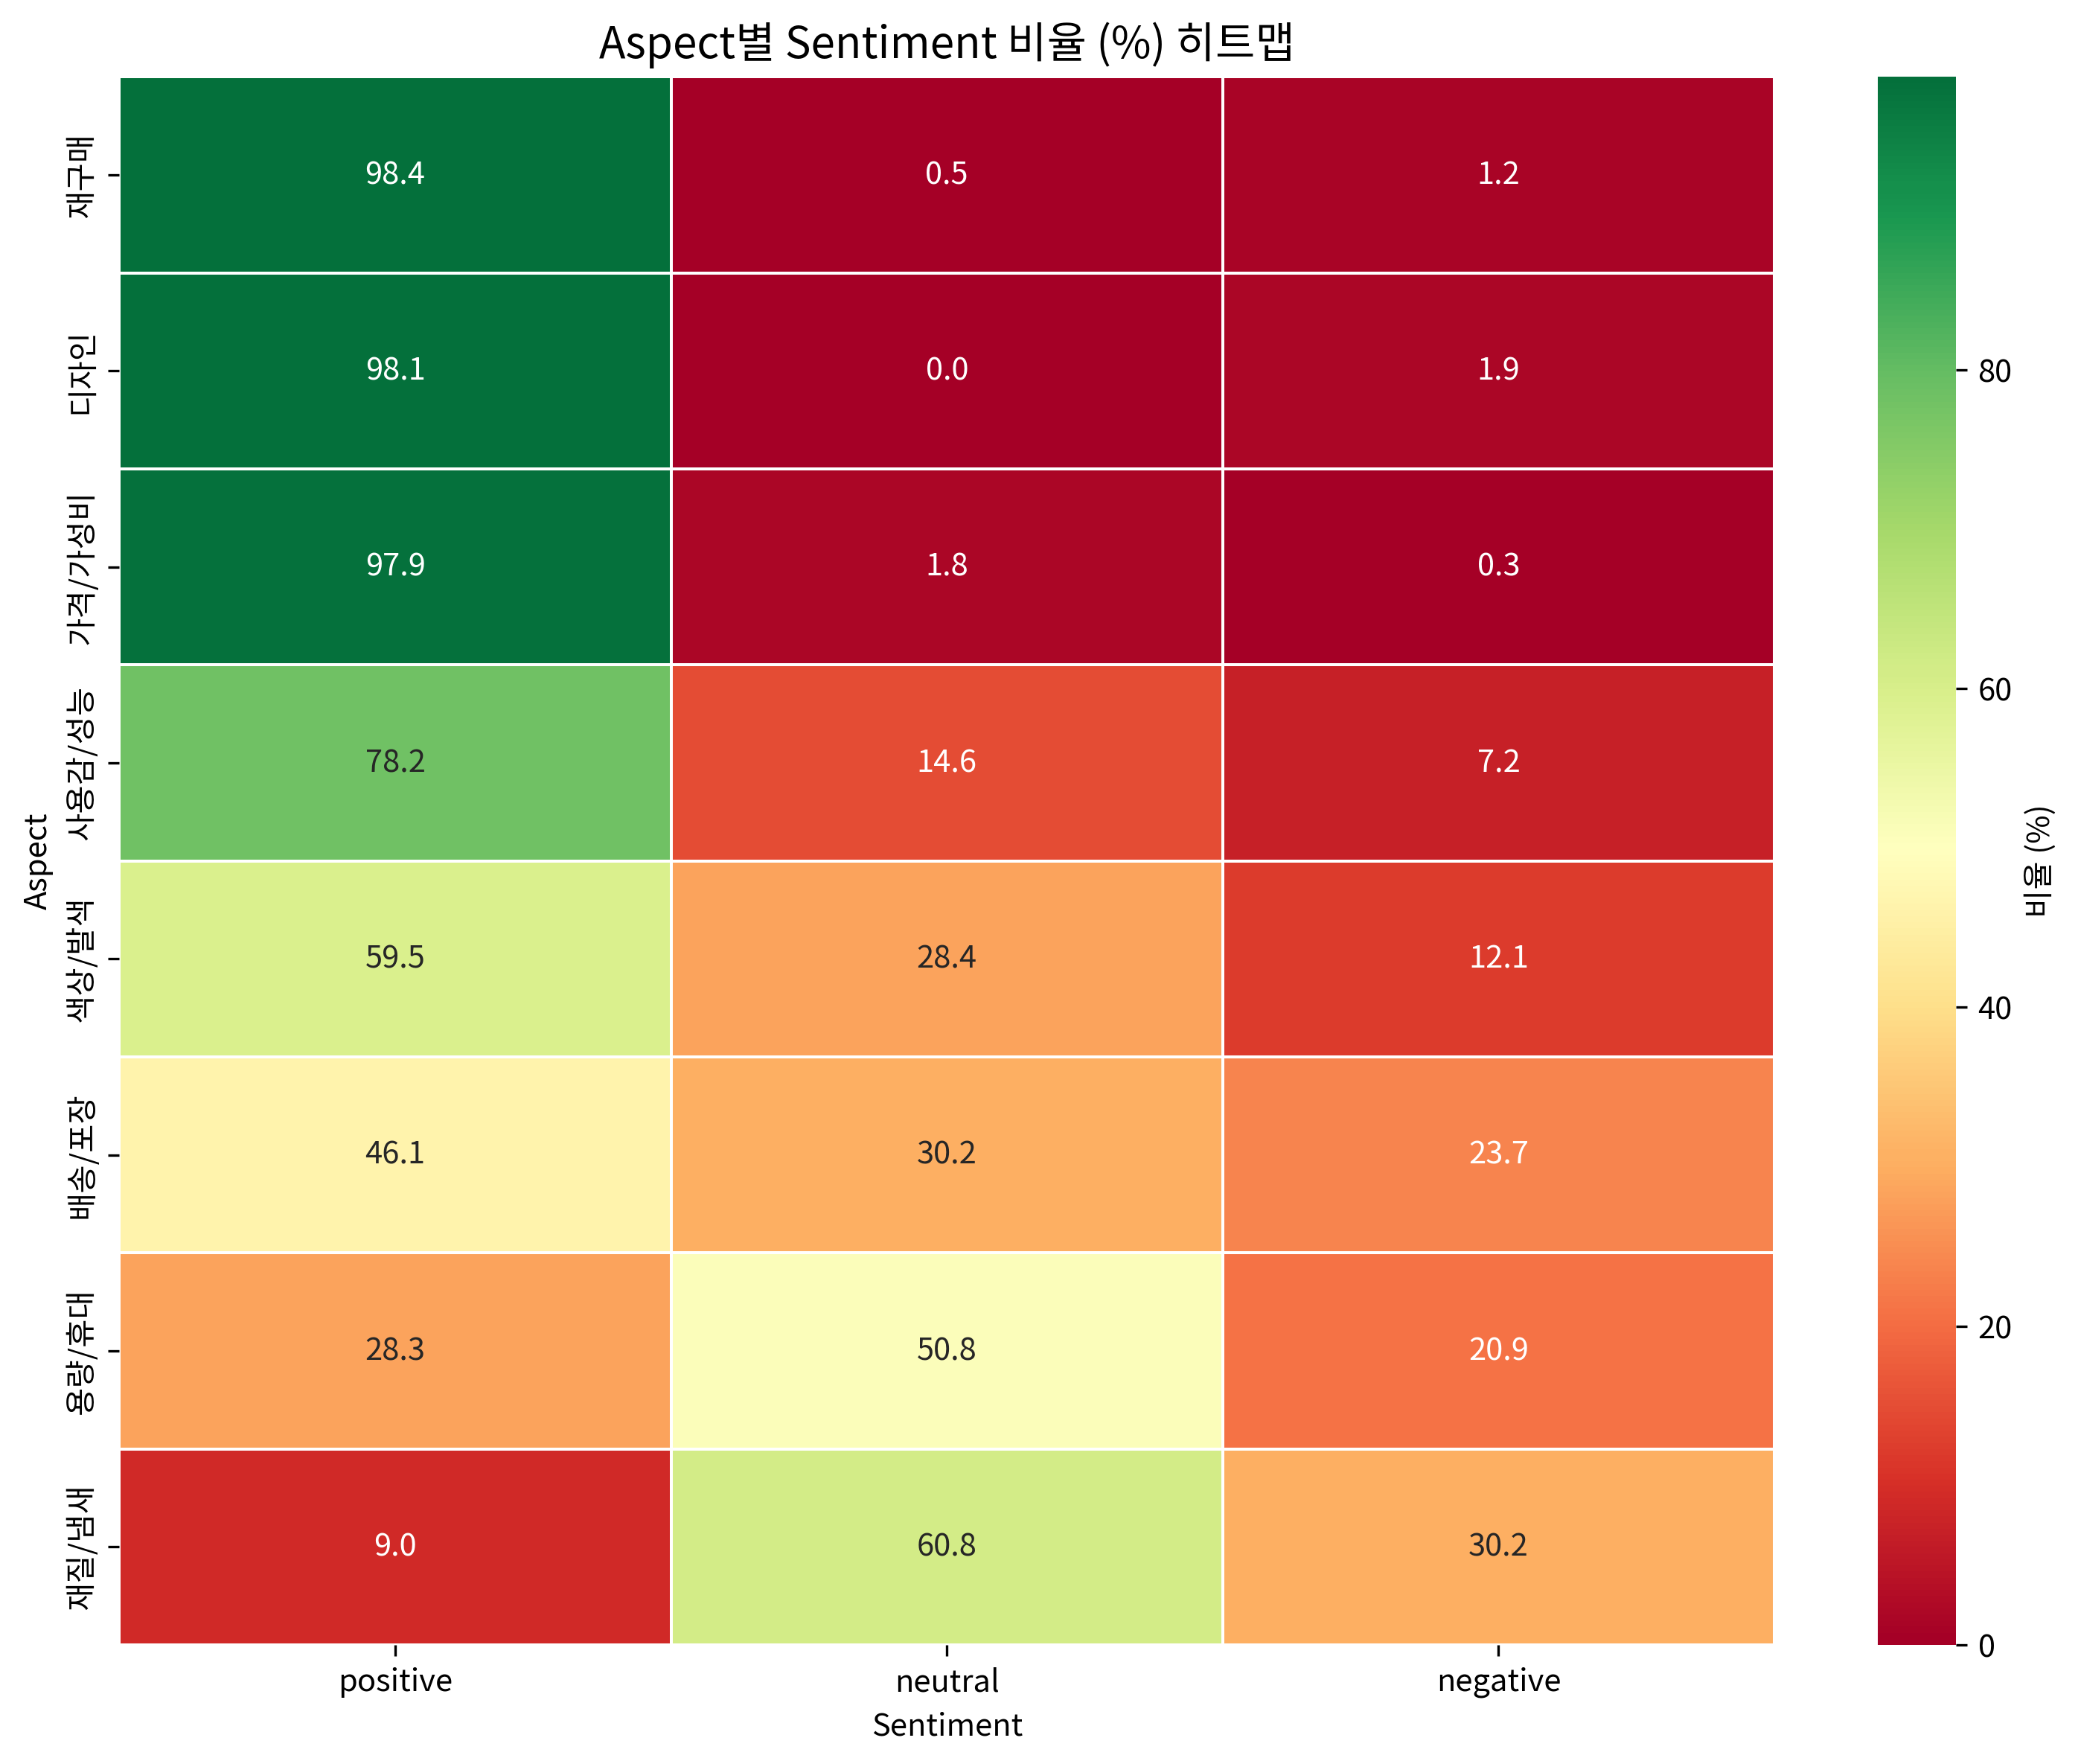

In [6]:
# 미분류 제외
df_real = df[df['aspect'] != '미분류'].copy()

# 크로스탭: Aspect × Sentiment 비율
cross = pd.crosstab(df_real['aspect'], df_real['aspect_sentiment'], normalize='index') * 100
cross = cross[['positive', 'neutral', 'negative']]
cross = cross.sort_values('positive', ascending=False)

# 히트맵
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=0.5, ax=ax, cbar_kws={'label': '비율 (%)'})
ax.set_title('Aspect별 Sentiment 비율 (%) 히트맵', fontsize=14)
ax.set_ylabel('Aspect')
ax.set_xlabel('Sentiment')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/03_Aspect_Sentiment_히트맵.png', dpi=300, bbox_inches='tight')
plt.show()

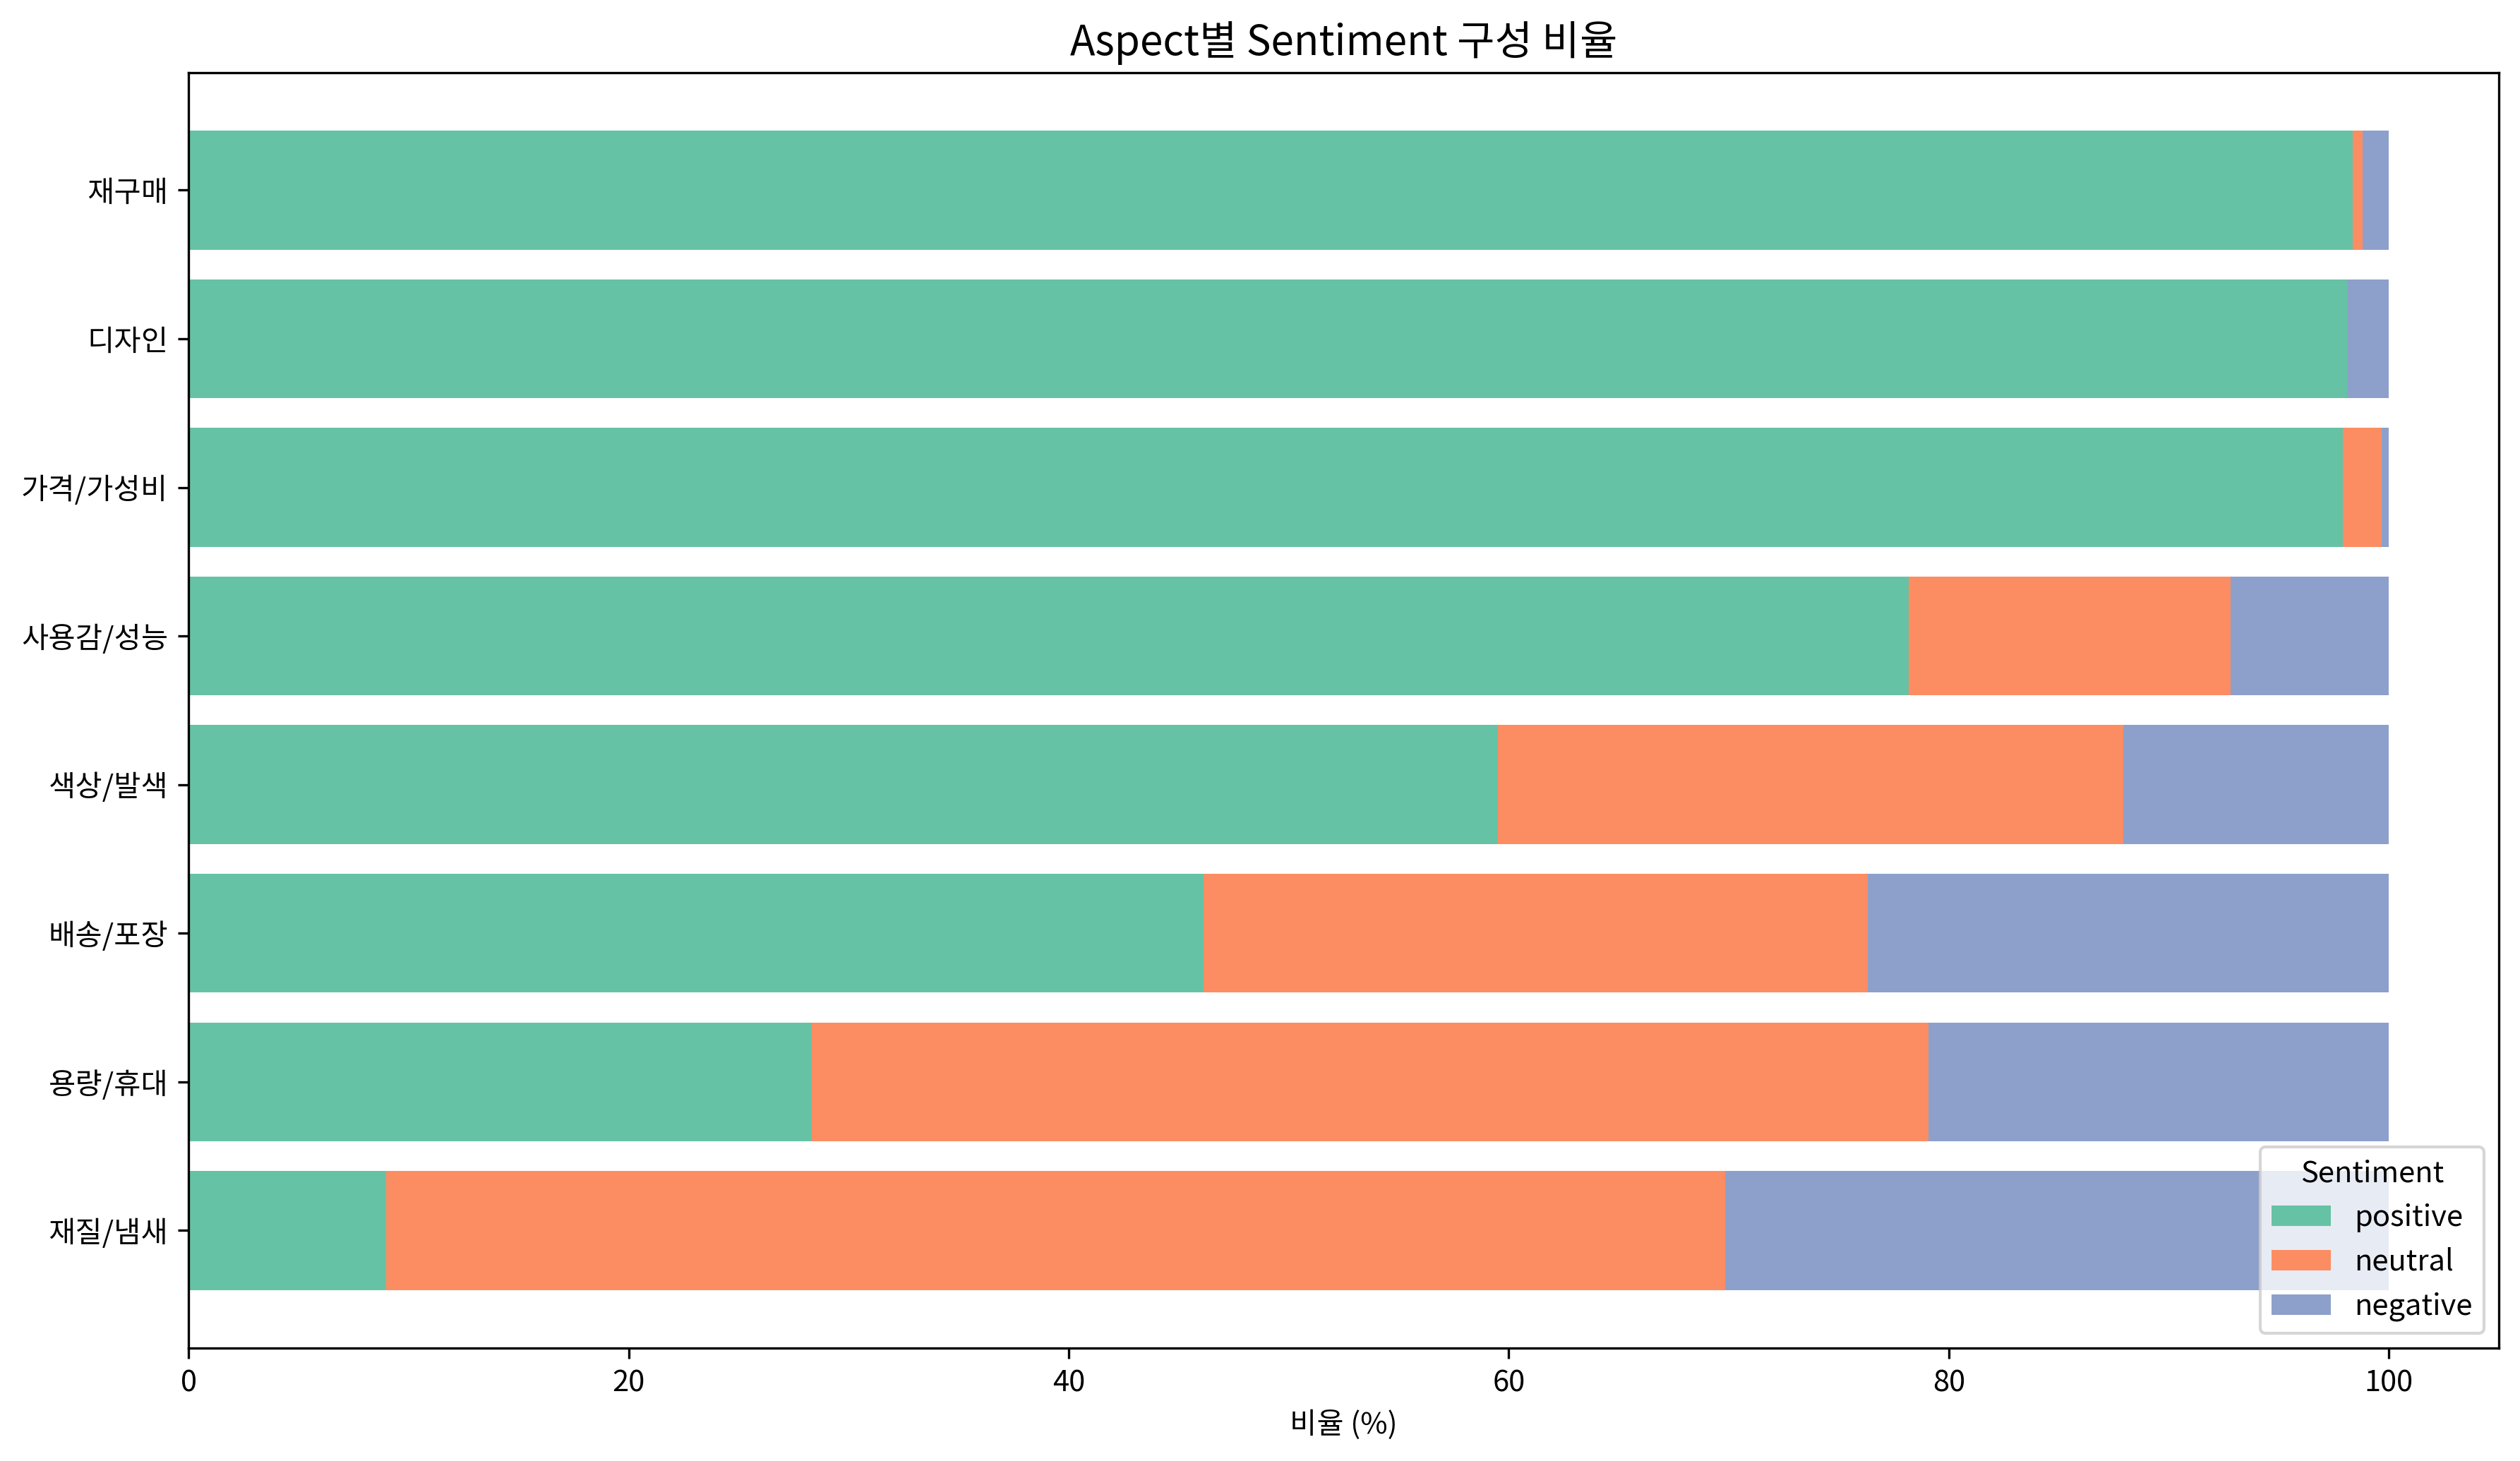

In [7]:
# 스택 막대그래프
cross_sorted = cross.sort_values('positive', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = {'positive': '#66c2a5', 'neutral': '#fc8d62', 'negative': '#8da0cb'}

left = np.zeros(len(cross_sorted))
for sentiment in ['positive', 'neutral', 'negative']:
    ax.barh(cross_sorted.index, cross_sorted[sentiment], left=left,
            label=sentiment, color=colors[sentiment])
    left += cross_sorted[sentiment].values

ax.set_title('Aspect별 Sentiment 구성 비율', fontsize=14)
ax.set_xlabel('비율 (%)')
ax.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/04_Aspect_Sentiment_스택막대.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. 카테고리별 Aspect 비교

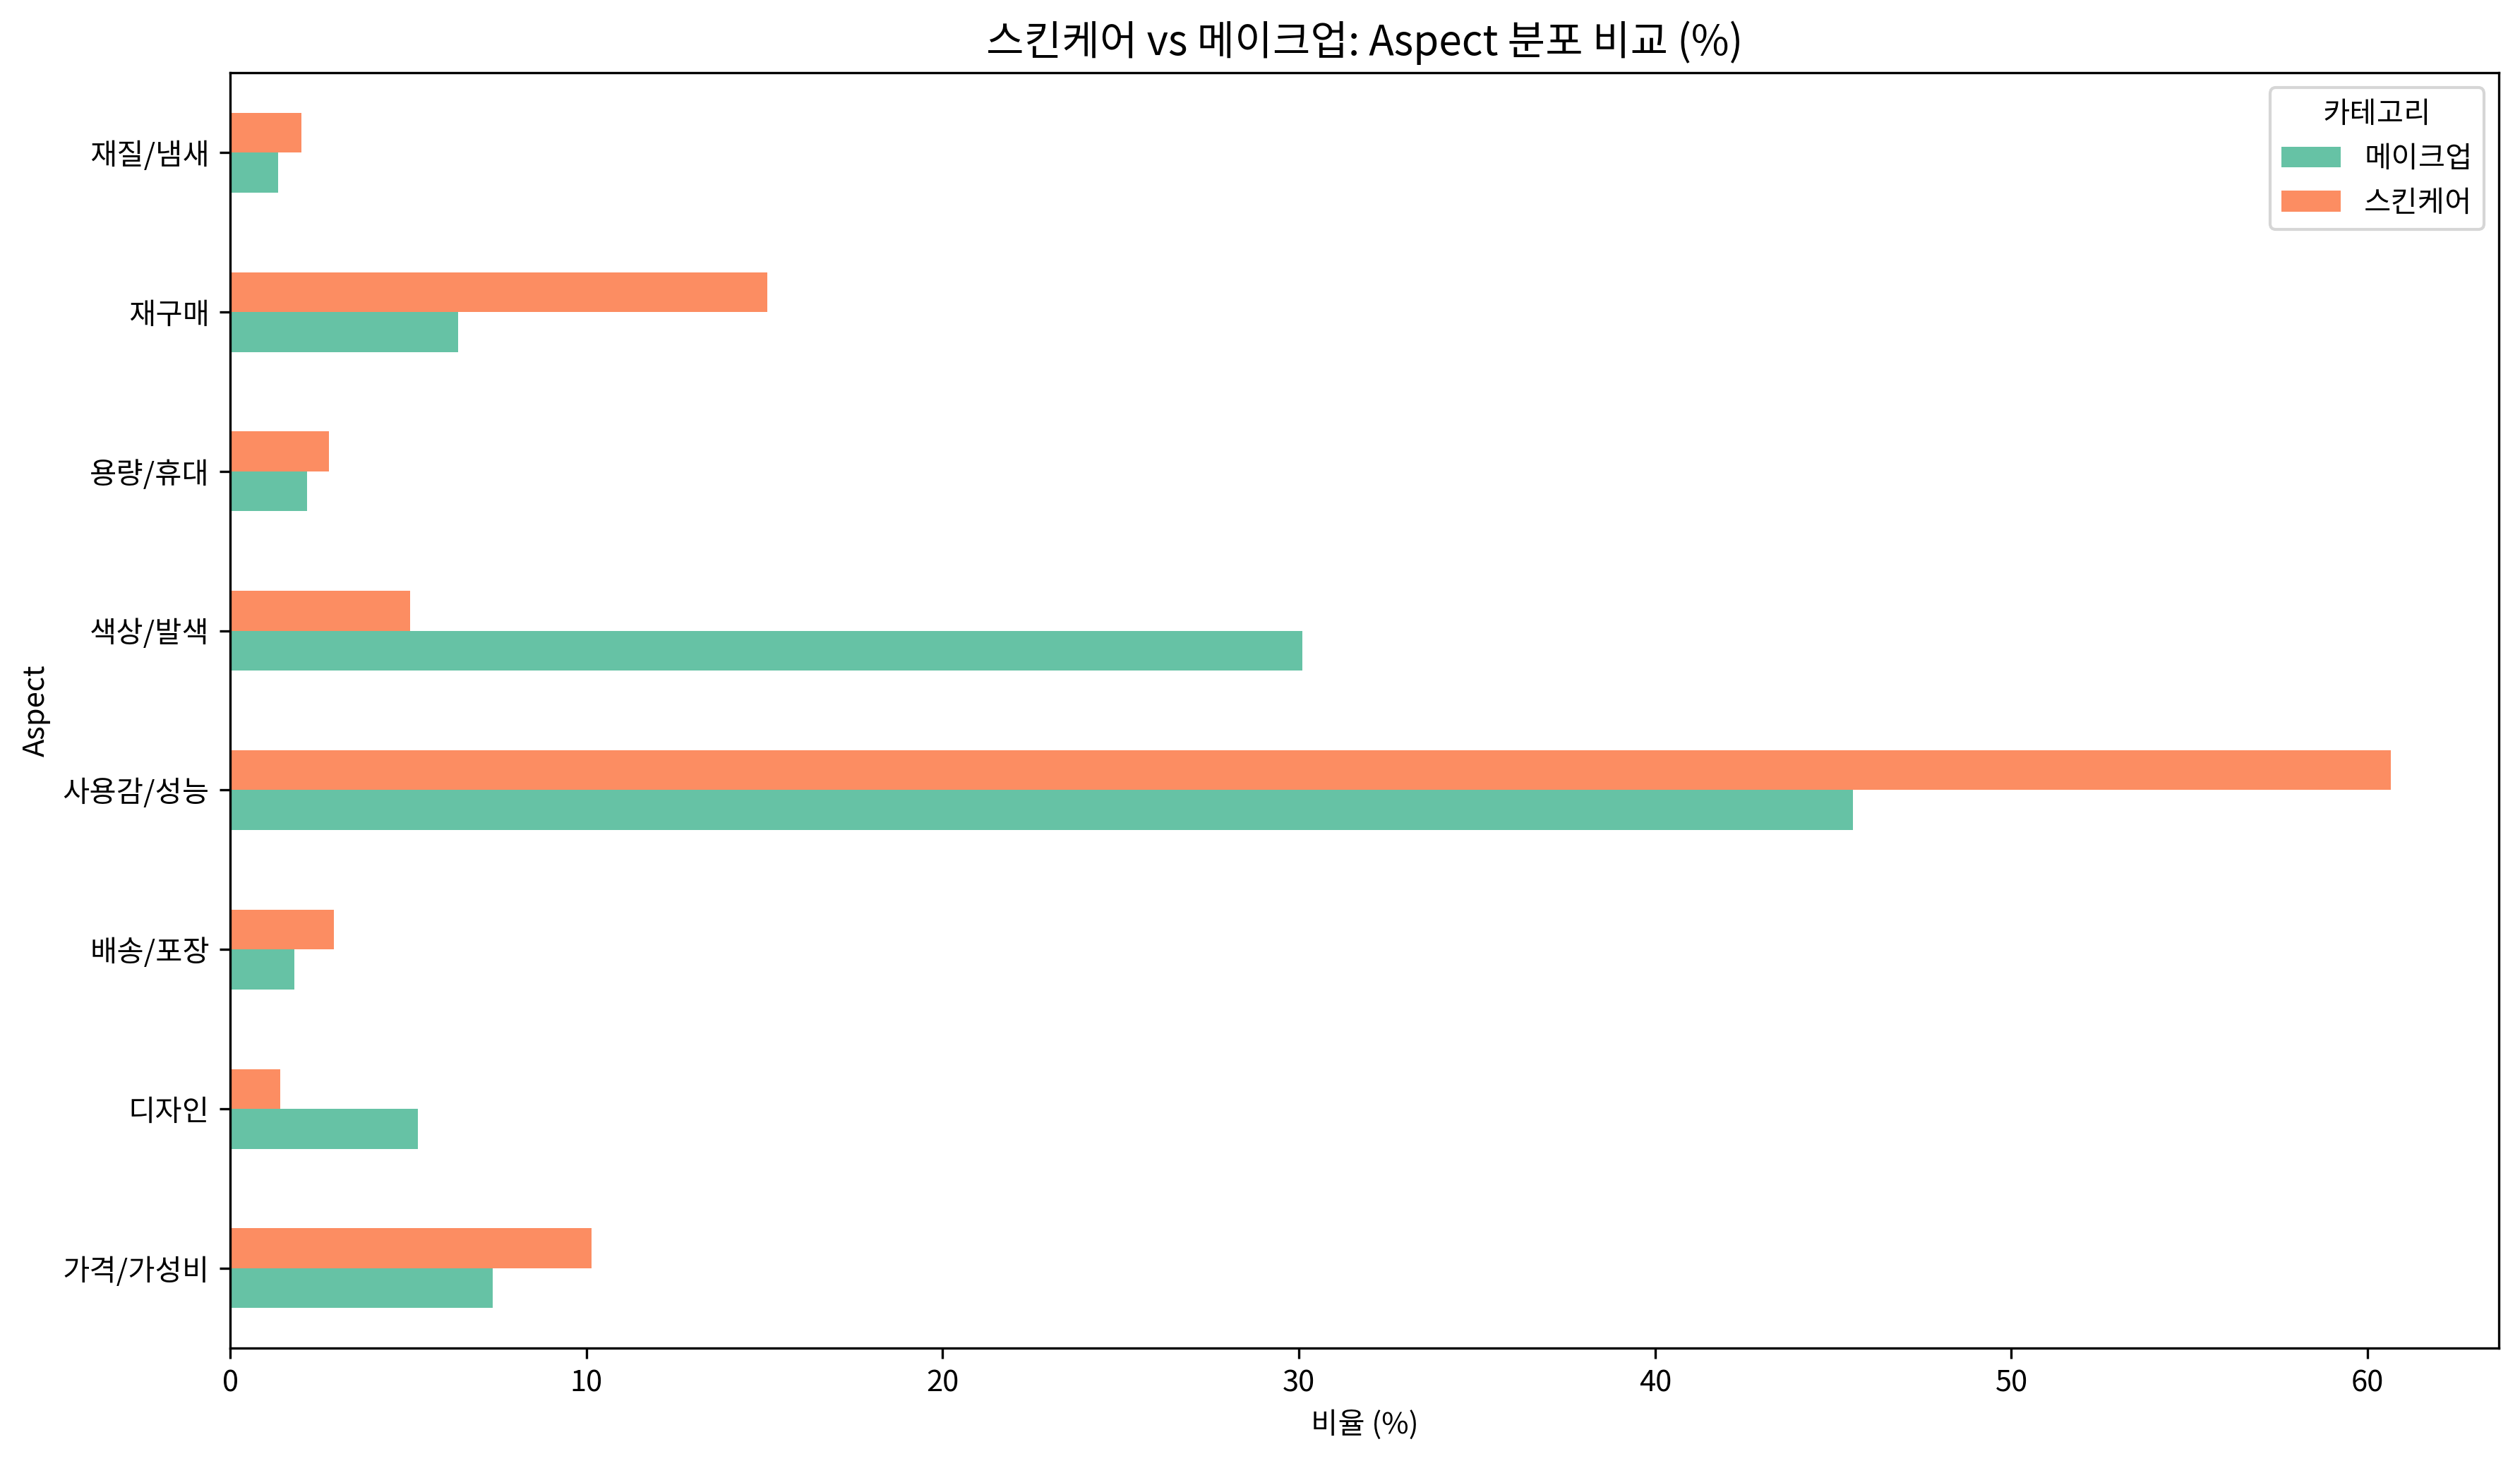

In [8]:
# 스킨케어 vs 메이크업 Aspect 분포 비교
df_cat = df_real[df_real['category_1'].isin(['스킨케어', '메이크업'])].copy()

cat_aspect = pd.crosstab(df_cat['aspect'], df_cat['category_1'], normalize='columns') * 100

fig, ax = plt.subplots(figsize=(12, 7))
cat_aspect.plot(kind='barh', ax=ax)
ax.set_title('스킨케어 vs 메이크업: Aspect 분포 비교 (%)', fontsize=14)
ax.set_xlabel('비율 (%)')
ax.set_ylabel('Aspect')
ax.legend(title='카테고리')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/05_스킨케어_vs_메이크업.png', dpi=300, bbox_inches='tight')
plt.show()

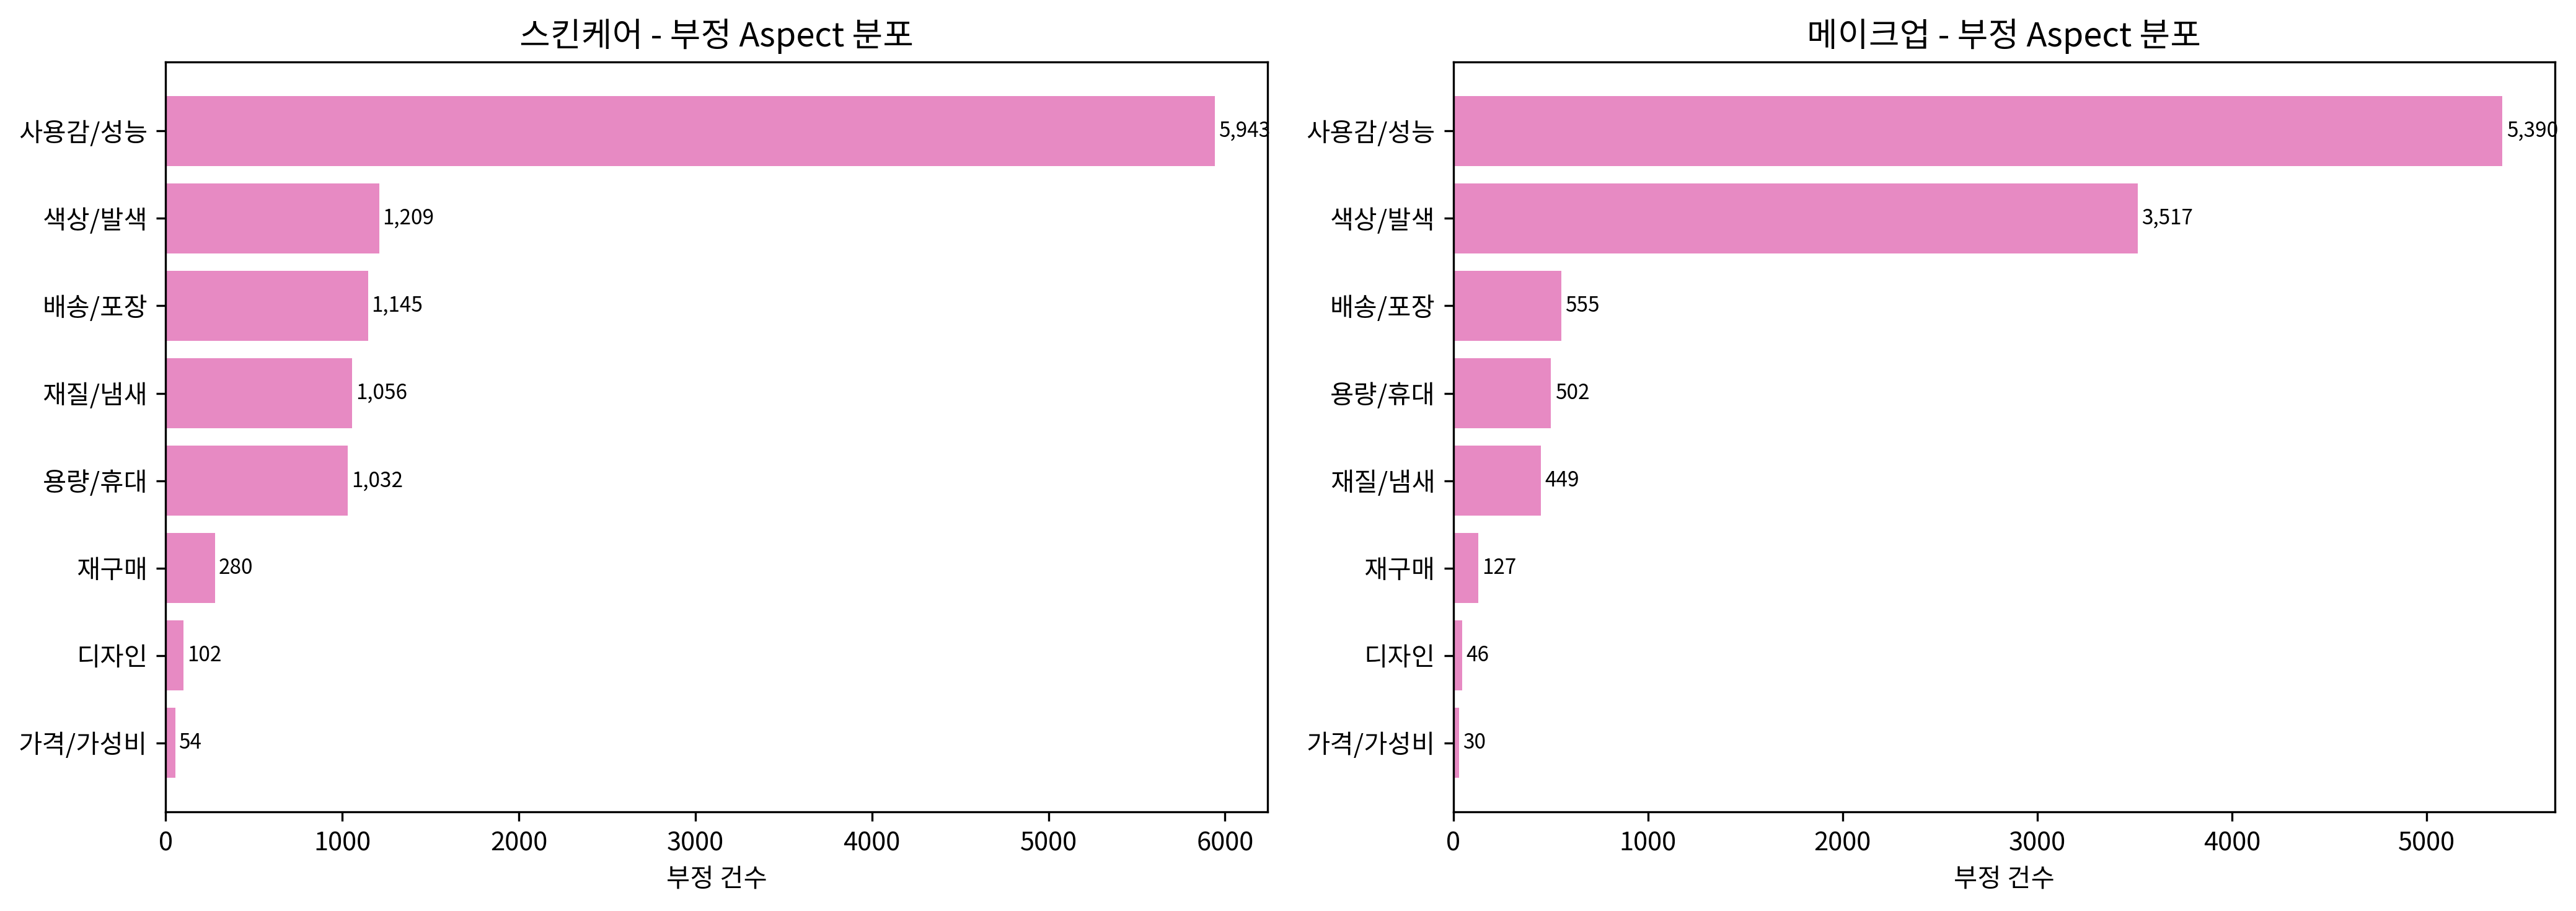

In [9]:
# 카테고리별 주요 부정 Aspect
df_neg = df_cat[df_cat['aspect_sentiment'] == 'negative']
cat_neg_aspect = pd.crosstab(df_neg['aspect'], df_neg['category_1'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cat in enumerate(['스킨케어', '메이크업']):
    if cat in cat_neg_aspect.columns:
        data = cat_neg_aspect[cat].sort_values(ascending=True)
        axes[i].barh(data.index, data.values, color='#e78ac3')
        axes[i].set_title(f'{cat} - 부정 Aspect 분포', fontsize=13)
        axes[i].set_xlabel('부정 건수')
        for j, v in enumerate(data.values):
            axes[i].text(v + 20, j, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/06_카테고리별_부정_Aspect.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# category_2(소분류)별 상위 Aspect Top 3
cat2_aspect = df_real.dropna(subset=['category_2']).groupby(
    ['category_2', 'aspect']).size().reset_index(name='count')
cat2_top = cat2_aspect.sort_values(
    ['category_2', 'count'], ascending=[True, False])
cat2_top = cat2_top.groupby('category_2').head(3)
cat2_top['rank'] = cat2_top.groupby('category_2').cumcount() + 1

print("소분류별 상위 3 Aspect:")
print("=" * 60)
for cat2 in cat2_top['category_2'].unique():
    subset = cat2_top[cat2_top['category_2'] == cat2]
    aspects = ', '.join([f"{r['aspect']}({r['count']:,})" for _, r in subset.iterrows()])
    print(f"  {cat2}: {aspects}")

소분류별 상위 3 Aspect:
  기초스킨케어: 사용감/성능(74,008), 재구매(19,641), 가격/가성비(11,327)
  남성메이크업: 사용감/성능(44), 가격/가성비(15), 색상/발색(15)
  남성스킨케어: 사용감/성능(1,099), 색상/발색(355), 가격/가성비(354)
  남성용면도기: 사용감/성능(462), 가격/가성비(254), 재구매(108)
  남성향수: 사용감/성능(481), 색상/발색(284), 재질/냄새(241)
  립메이크업: 색상/발색(13,492), 사용감/성능(13,374), 디자인(2,452)
  립케어: 사용감/성능(2,988), 색상/발색(1,031), 가격/가성비(687)
  베이스메이크업: 사용감/성능(14,654), 색상/발색(3,550), 가격/가성비(2,463)
  아이메이크업: 사용감/성능(11,342), 색상/발색(7,191), 가격/가성비(2,162)
  자외선차단제: 사용감/성능(6,185), 색상/발색(1,170), 재구매(1,130)
  치크/하이라이터: 사용감/성능(6,094), 색상/발색(5,798), 디자인(1,030)
  클렌징/쉐이빙: 사용감/성능(244), 가격/가성비(111), 재구매(70)
  클렌징/필링: 사용감/성능(11,278), 가격/가성비(2,274), 재구매(2,205)
  팩/마스크: 사용감/성능(17,269), 재구매(4,360), 가격/가성비(3,332)


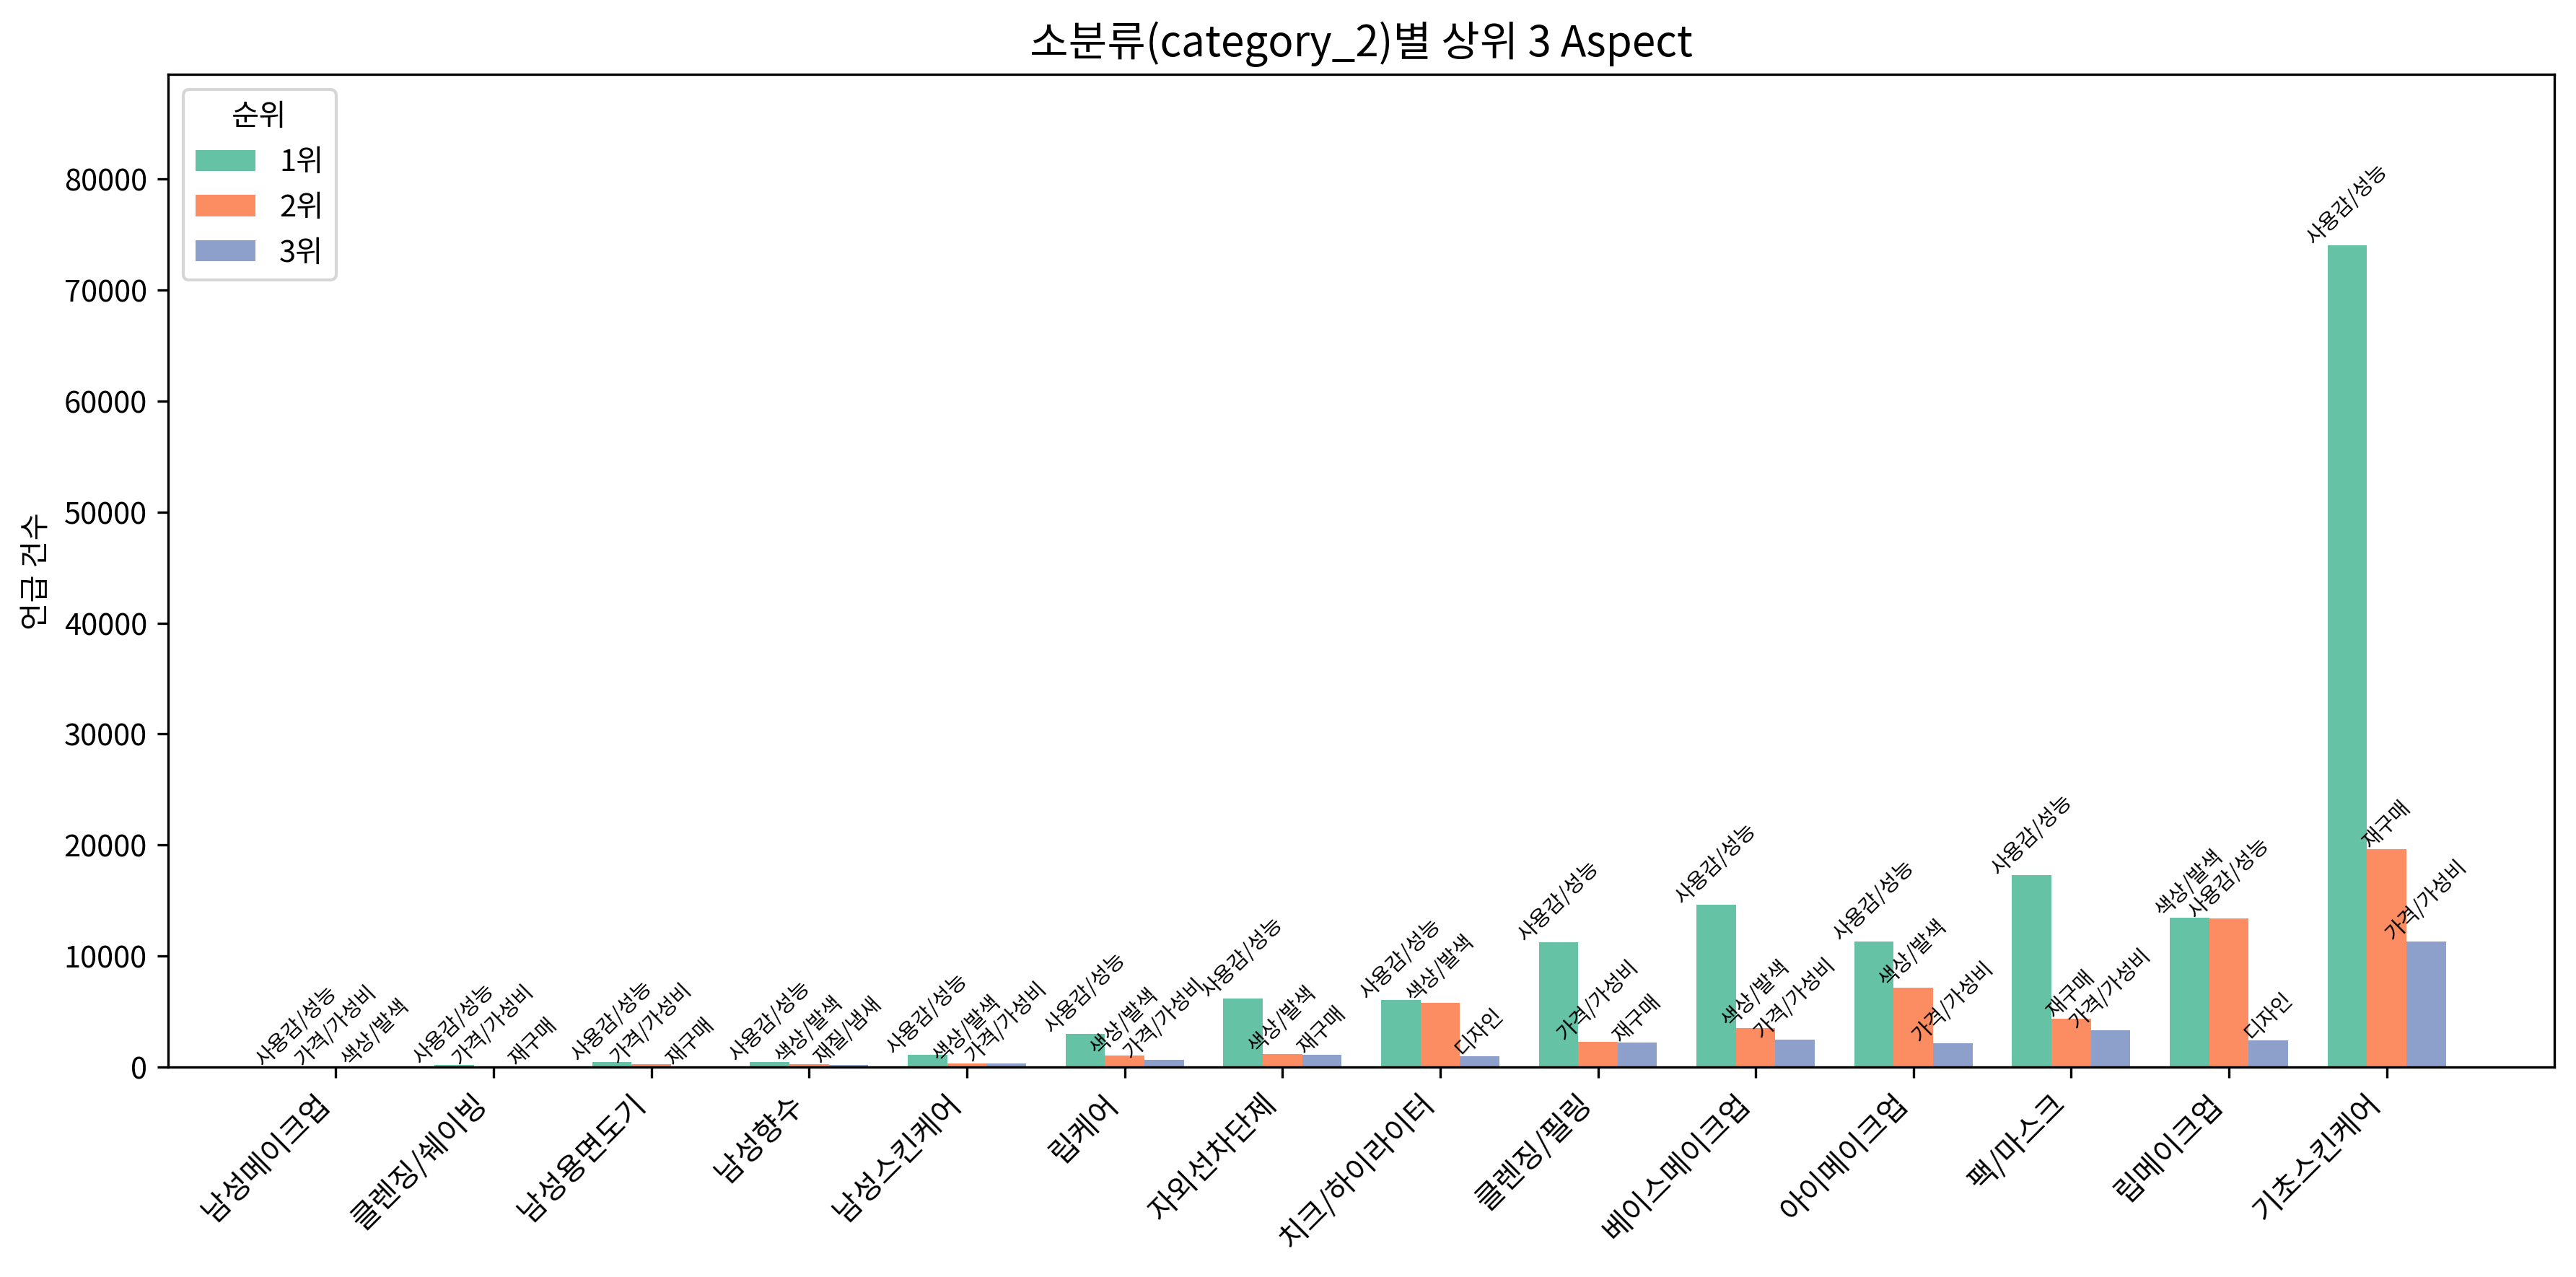

In [11]:
# 소분류별 상위 3 Aspect 그룹
fig, ax = plt.subplots(figsize=(12, 6))
cat2_order = cat2_top.groupby('category_2')['count'].sum().sort_values(ascending=True).index
cat2_top_sorted = cat2_top.set_index('category_2').loc[cat2_order].reset_index()
x_labels = cat2_top_sorted['category_2'].unique()
x_pos = np.arange(len(x_labels))
width = 0.25
for i, rank in enumerate([1, 2, 3]):
    subset = cat2_top_sorted[cat2_top_sorted['rank'] == rank]
    subset = subset.set_index('category_2').reindex(x_labels).reset_index()
    vals = subset['count'].fillna(0).values
    labels = subset['aspect'].values
    bars = ax.bar(x_pos + (i - 1) * width, vals, width, label=f'{rank}위')
    for j, (v, l) in enumerate(zip(vals, labels)):
        if v > 0 and pd.notna(l):
            ax.text(x_pos[j] + (i - 1) * width, v + 100,
                    str(l)[:6], ha='center', fontsize=7, rotation=45)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel('언급 건수')
ax.set_title('소분류(category_2)별 상위 3 Aspect', fontsize=14)
ax.legend(title='순위')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/07_소분류별_상위3_Aspect.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. 재구매 vs 비재구매 분석

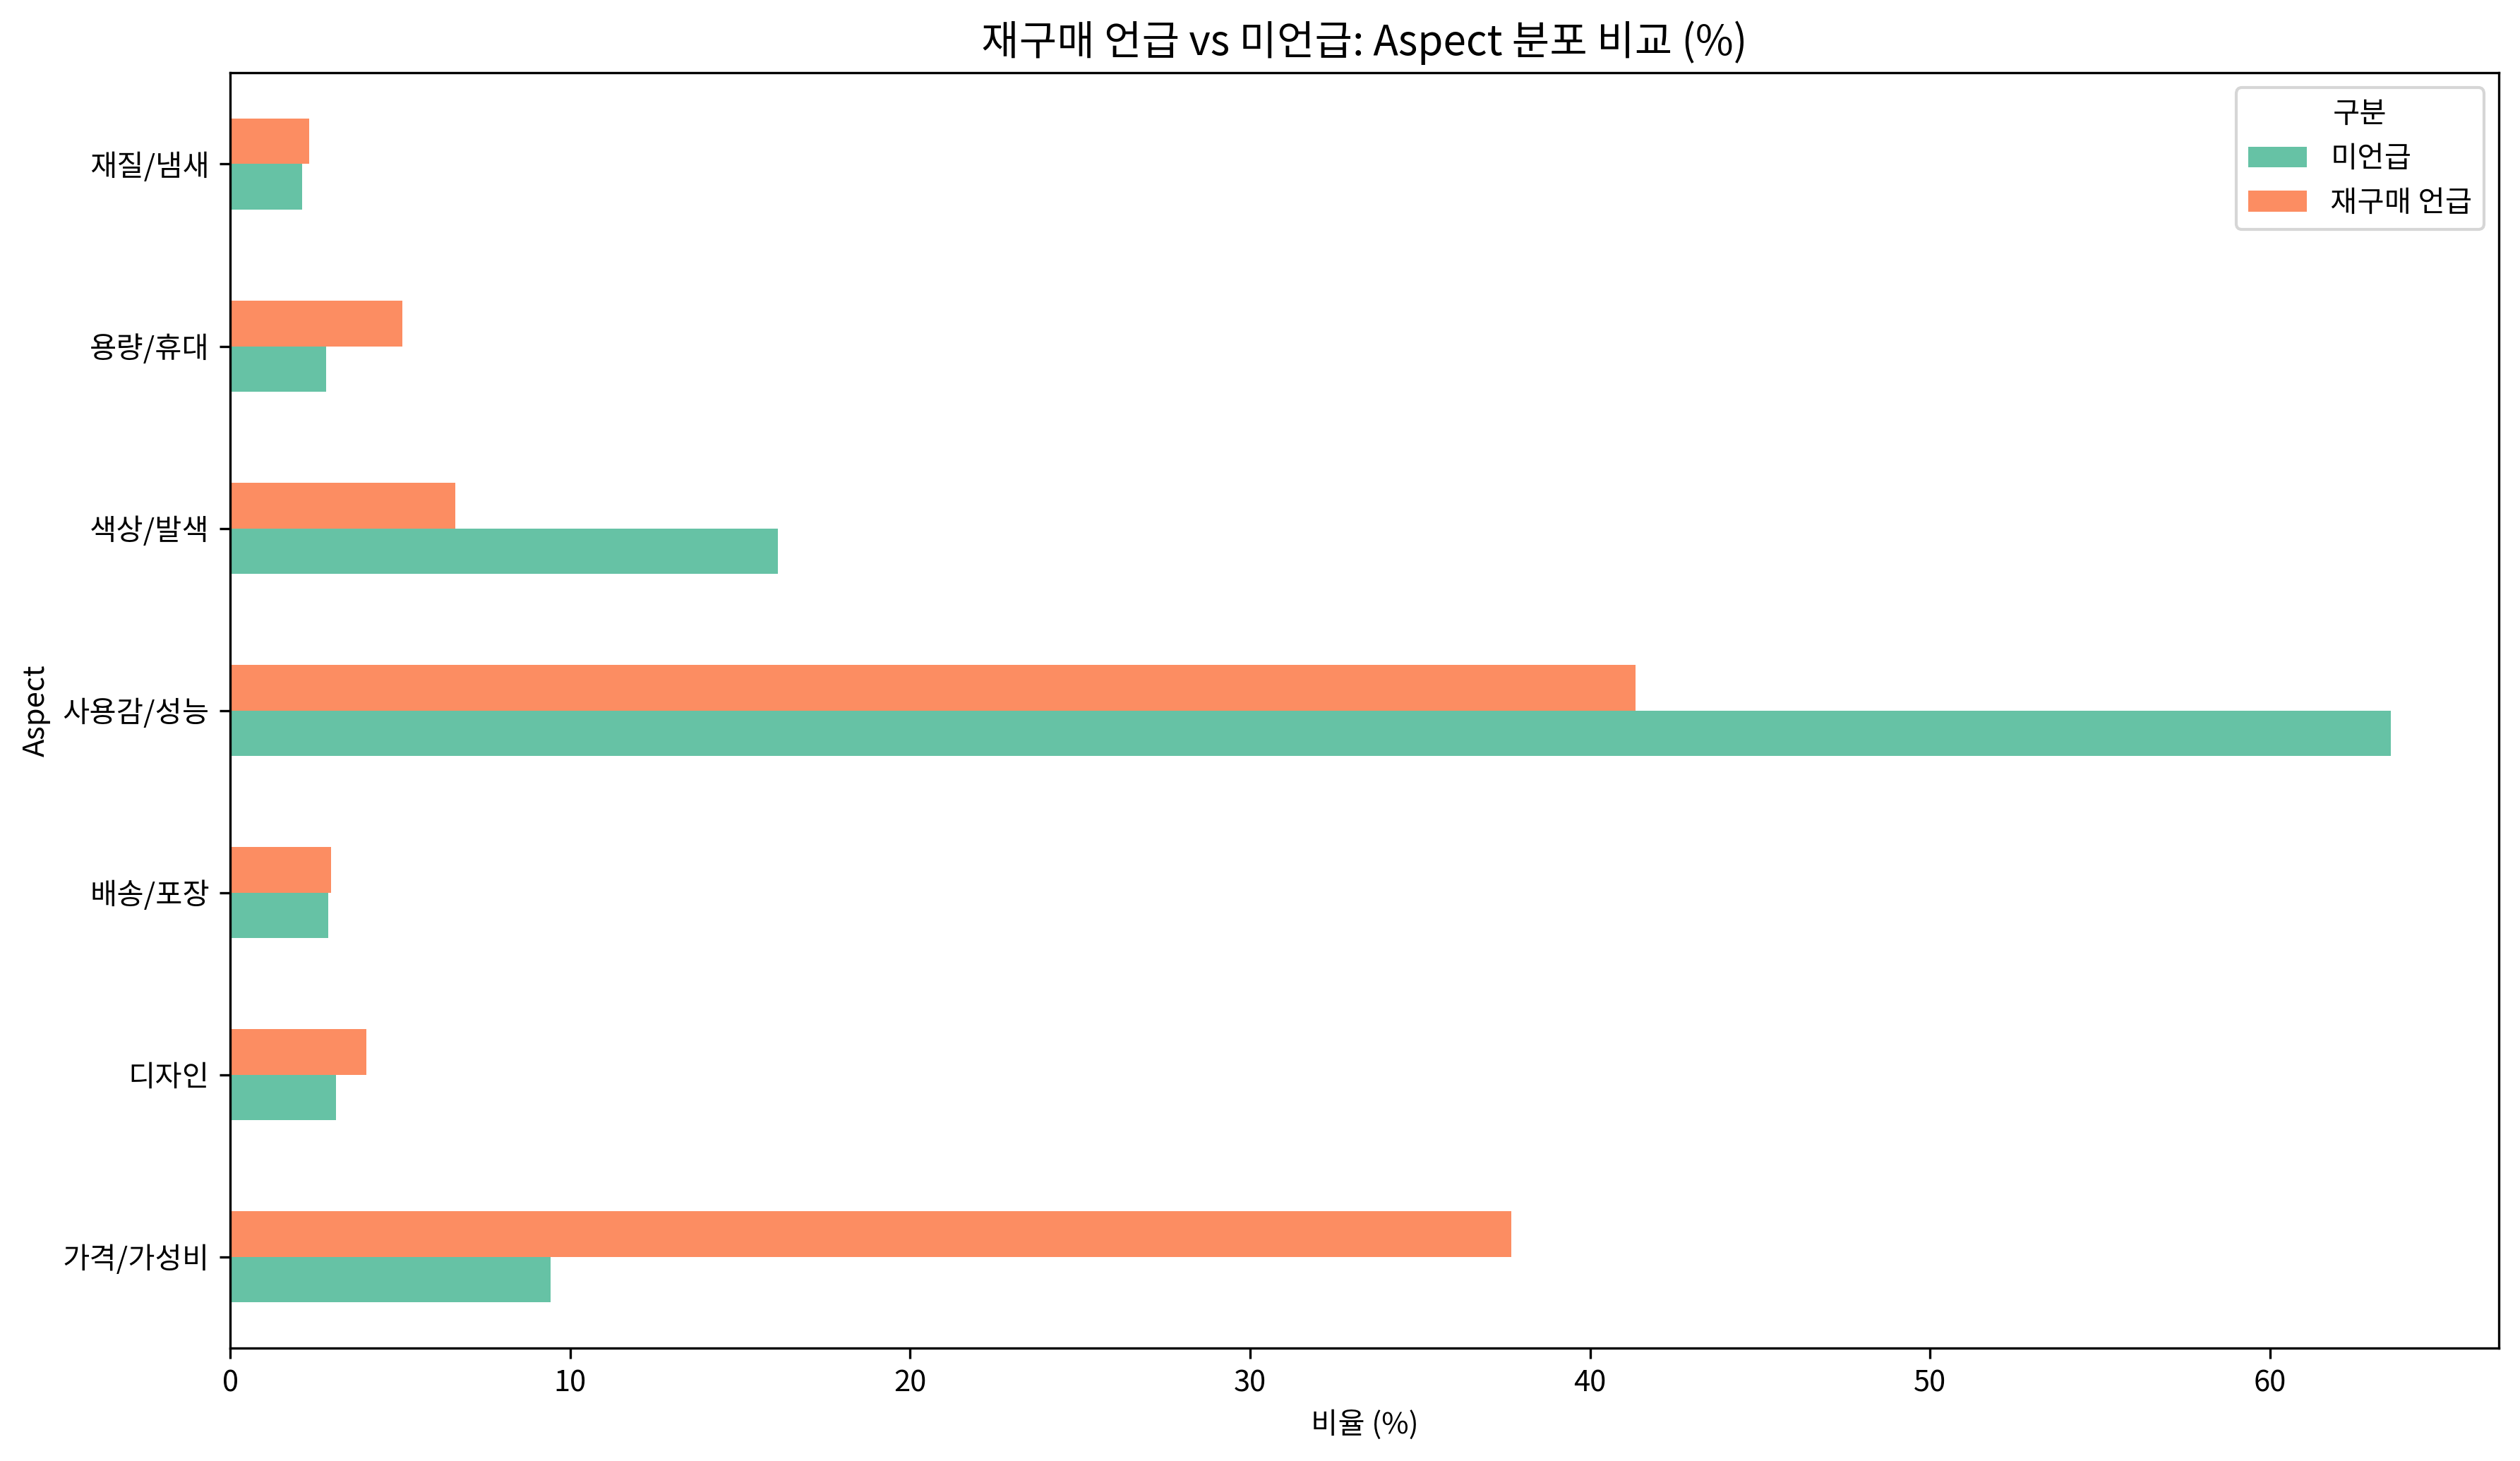

In [12]:
# 재구매 aspect: aspect_long에서 '재구매' 언급 여부로 판별
# review_level에서 aspect_labels에 '재구매' 포함 여부
df_review['has_repurchase'] = df_review['aspect_labels'].apply(
    lambda x: '재구매' in str(x))

# 재구매 언급 리뷰 vs 미언급 리뷰의 Aspect 분포 비교
df_reorder = df_real.merge(
    df_review[['review_id', 'has_repurchase']], on='review_id', how='left')
df_reorder = df_reorder[df_reorder['aspect'] != '재구매']  # 재구매 자체는 제외

reorder_aspect = pd.crosstab(
    df_reorder['aspect'],
    df_reorder['has_repurchase'].map({True: '재구매 언급', False: '미언급'}),
    normalize='columns') * 100

fig, ax = plt.subplots(figsize=(12, 7))
reorder_aspect.plot(kind='barh', ax=ax)
ax.set_title('재구매 언급 vs 미언급: Aspect 분포 비교 (%)', fontsize=14)
ax.set_xlabel('비율 (%)')
ax.set_ylabel('Aspect')
ax.legend(title='구분')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/08_재구매_vs_비재구매_분포.png', dpi=300, bbox_inches='tight')
plt.show()

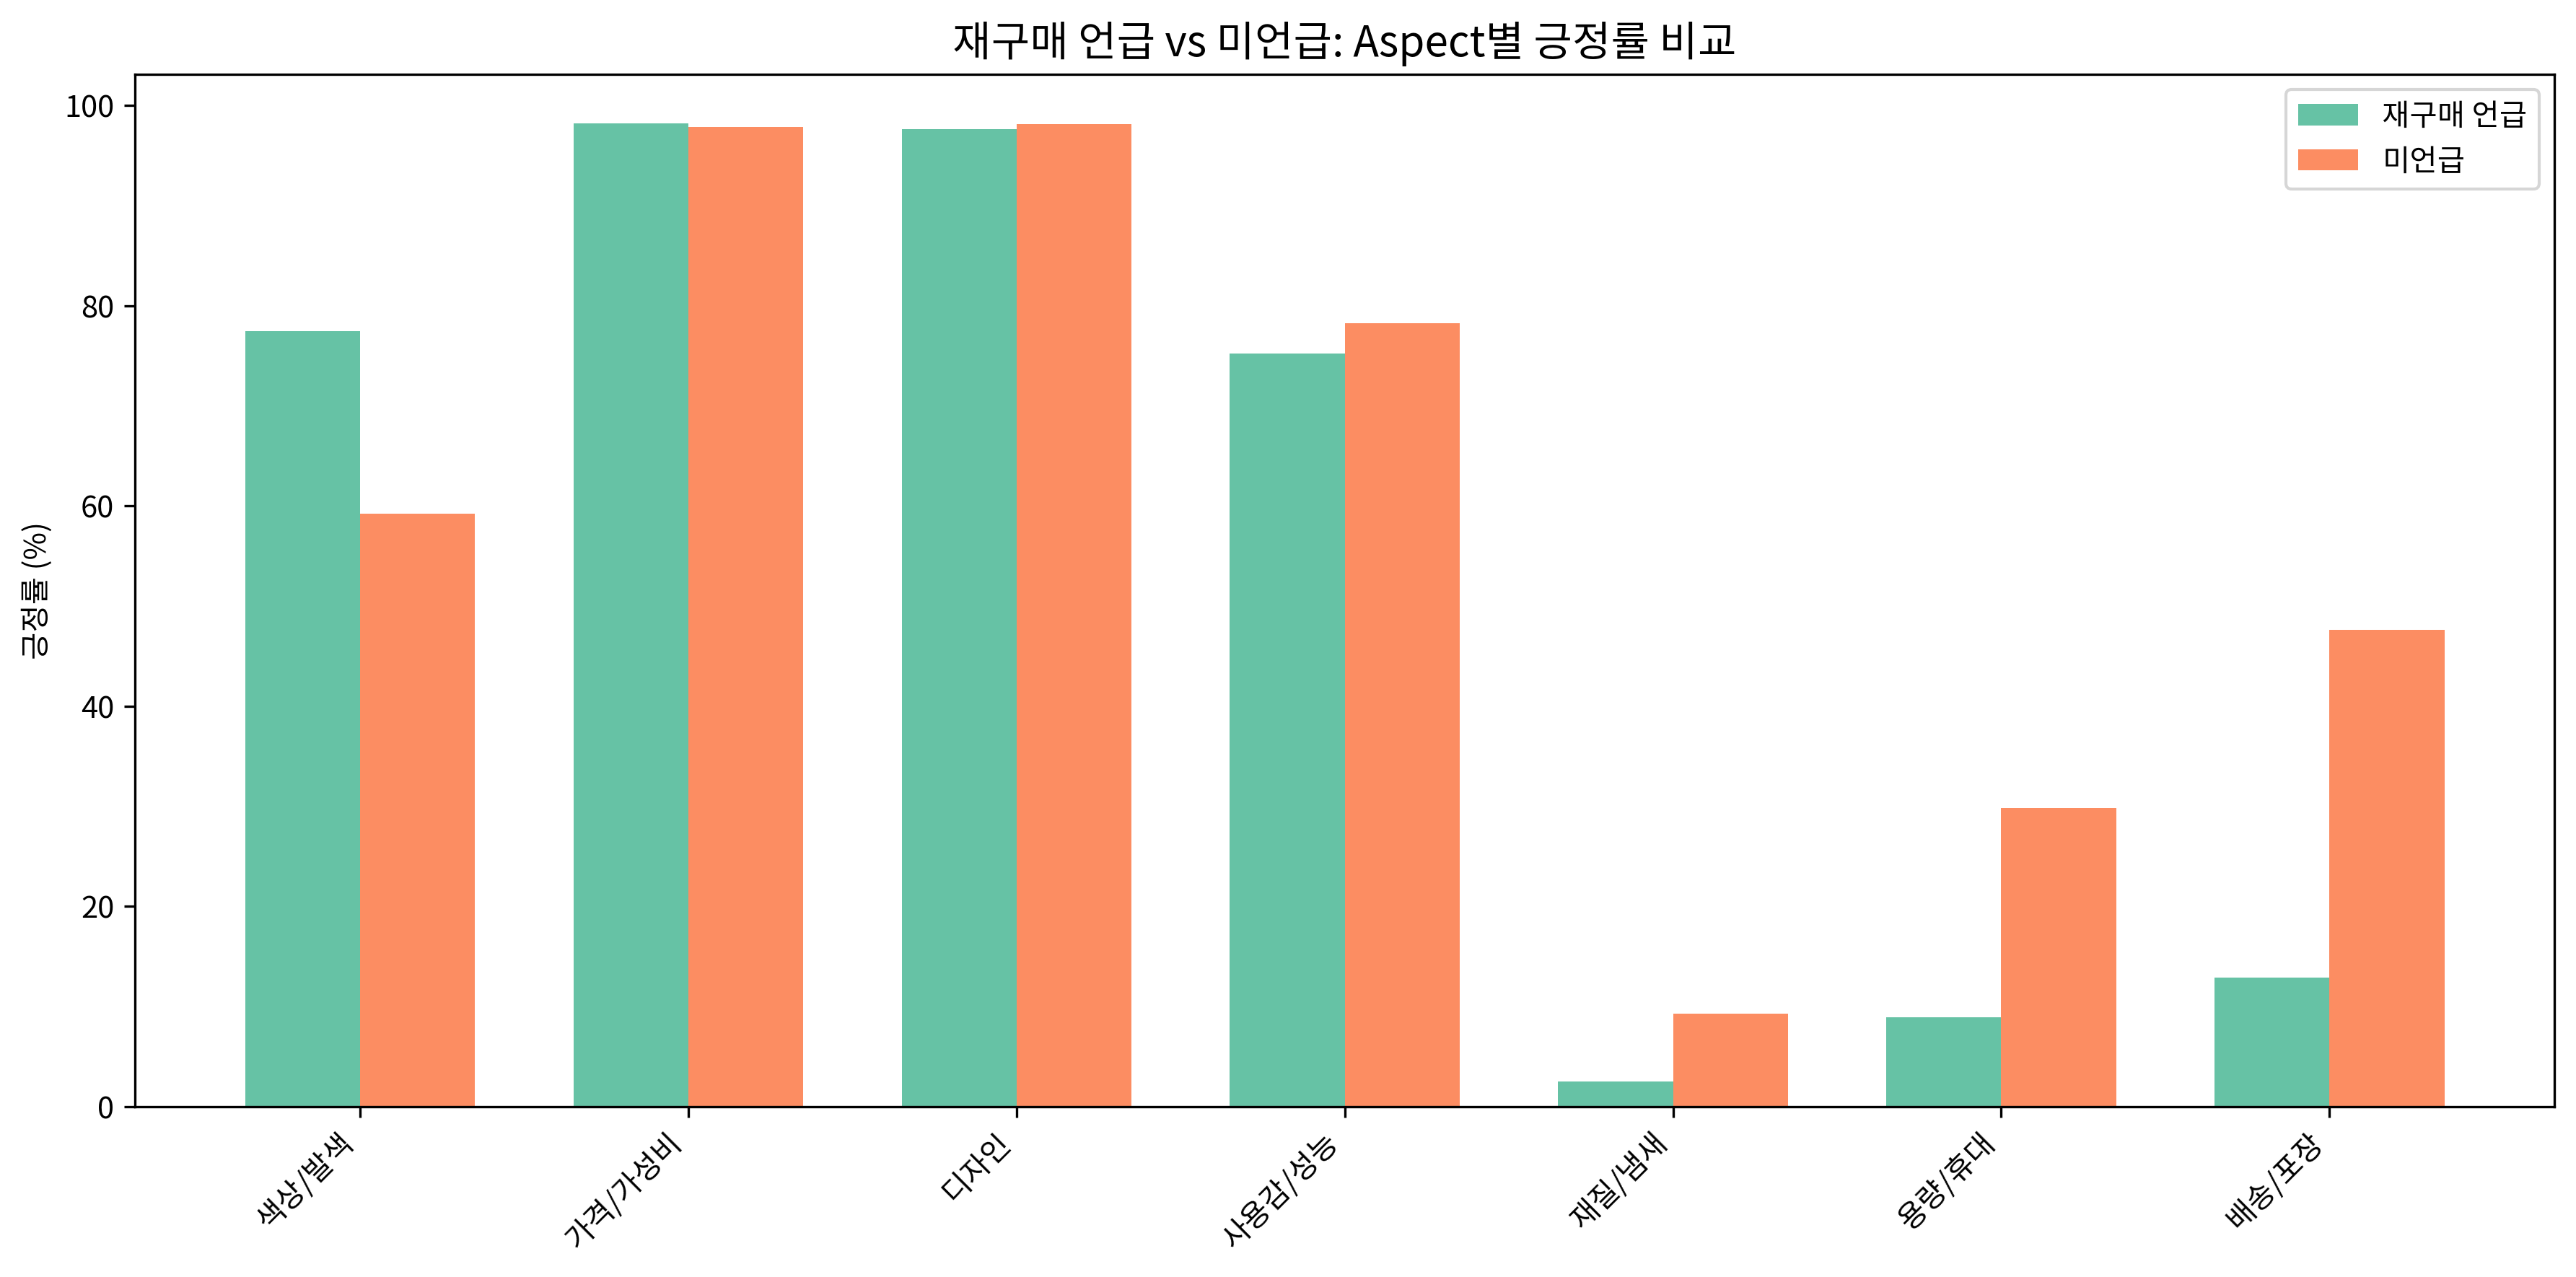

In [13]:
# 재구매 그룹의 긍정률 vs 비재구매 그룹
reorder_sent = df_reorder.groupby(
    ['has_repurchase', 'aspect', 'aspect_sentiment']).size().reset_index(name='count')
reorder_total = df_reorder.groupby(
    ['has_repurchase', 'aspect']).size().reset_index(name='total')
reorder_merged = reorder_sent.merge(reorder_total, on=['has_repurchase', 'aspect'])
reorder_merged['rate'] = reorder_merged['count'] / reorder_merged['total'] * 100

# 긍정률 비교
pos_rate = reorder_merged[reorder_merged['aspect_sentiment'] == 'positive'].copy()
pos_pivot = pos_rate.pivot_table(
    index='aspect', columns='has_repurchase', values='rate', fill_value=0)
pos_pivot.columns = ['미언급 긍정률', '재구매 언급 긍정률']
pos_pivot['차이'] = pos_pivot['재구매 언급 긍정률'] - pos_pivot['미언급 긍정률']
pos_pivot = pos_pivot.sort_values('차이', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pos_pivot))
width = 0.35
ax.bar(x - width/2, pos_pivot['재구매 언급 긍정률'], width,
       label='재구매 언급', color='#66c2a5')
ax.bar(x + width/2, pos_pivot['미언급 긍정률'], width,
       label='미언급', color='#fc8d62')
ax.set_xticks(x)
ax.set_xticklabels(pos_pivot.index, rotation=45, ha='right')
ax.set_title('재구매 언급 vs 미언급: Aspect별 긍정률 비교', fontsize=14)
ax.set_ylabel('긍정률 (%)')
ax.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/09_재구매_vs_비재구매_긍정률.png', dpi=300, bbox_inches='tight')
plt.show()

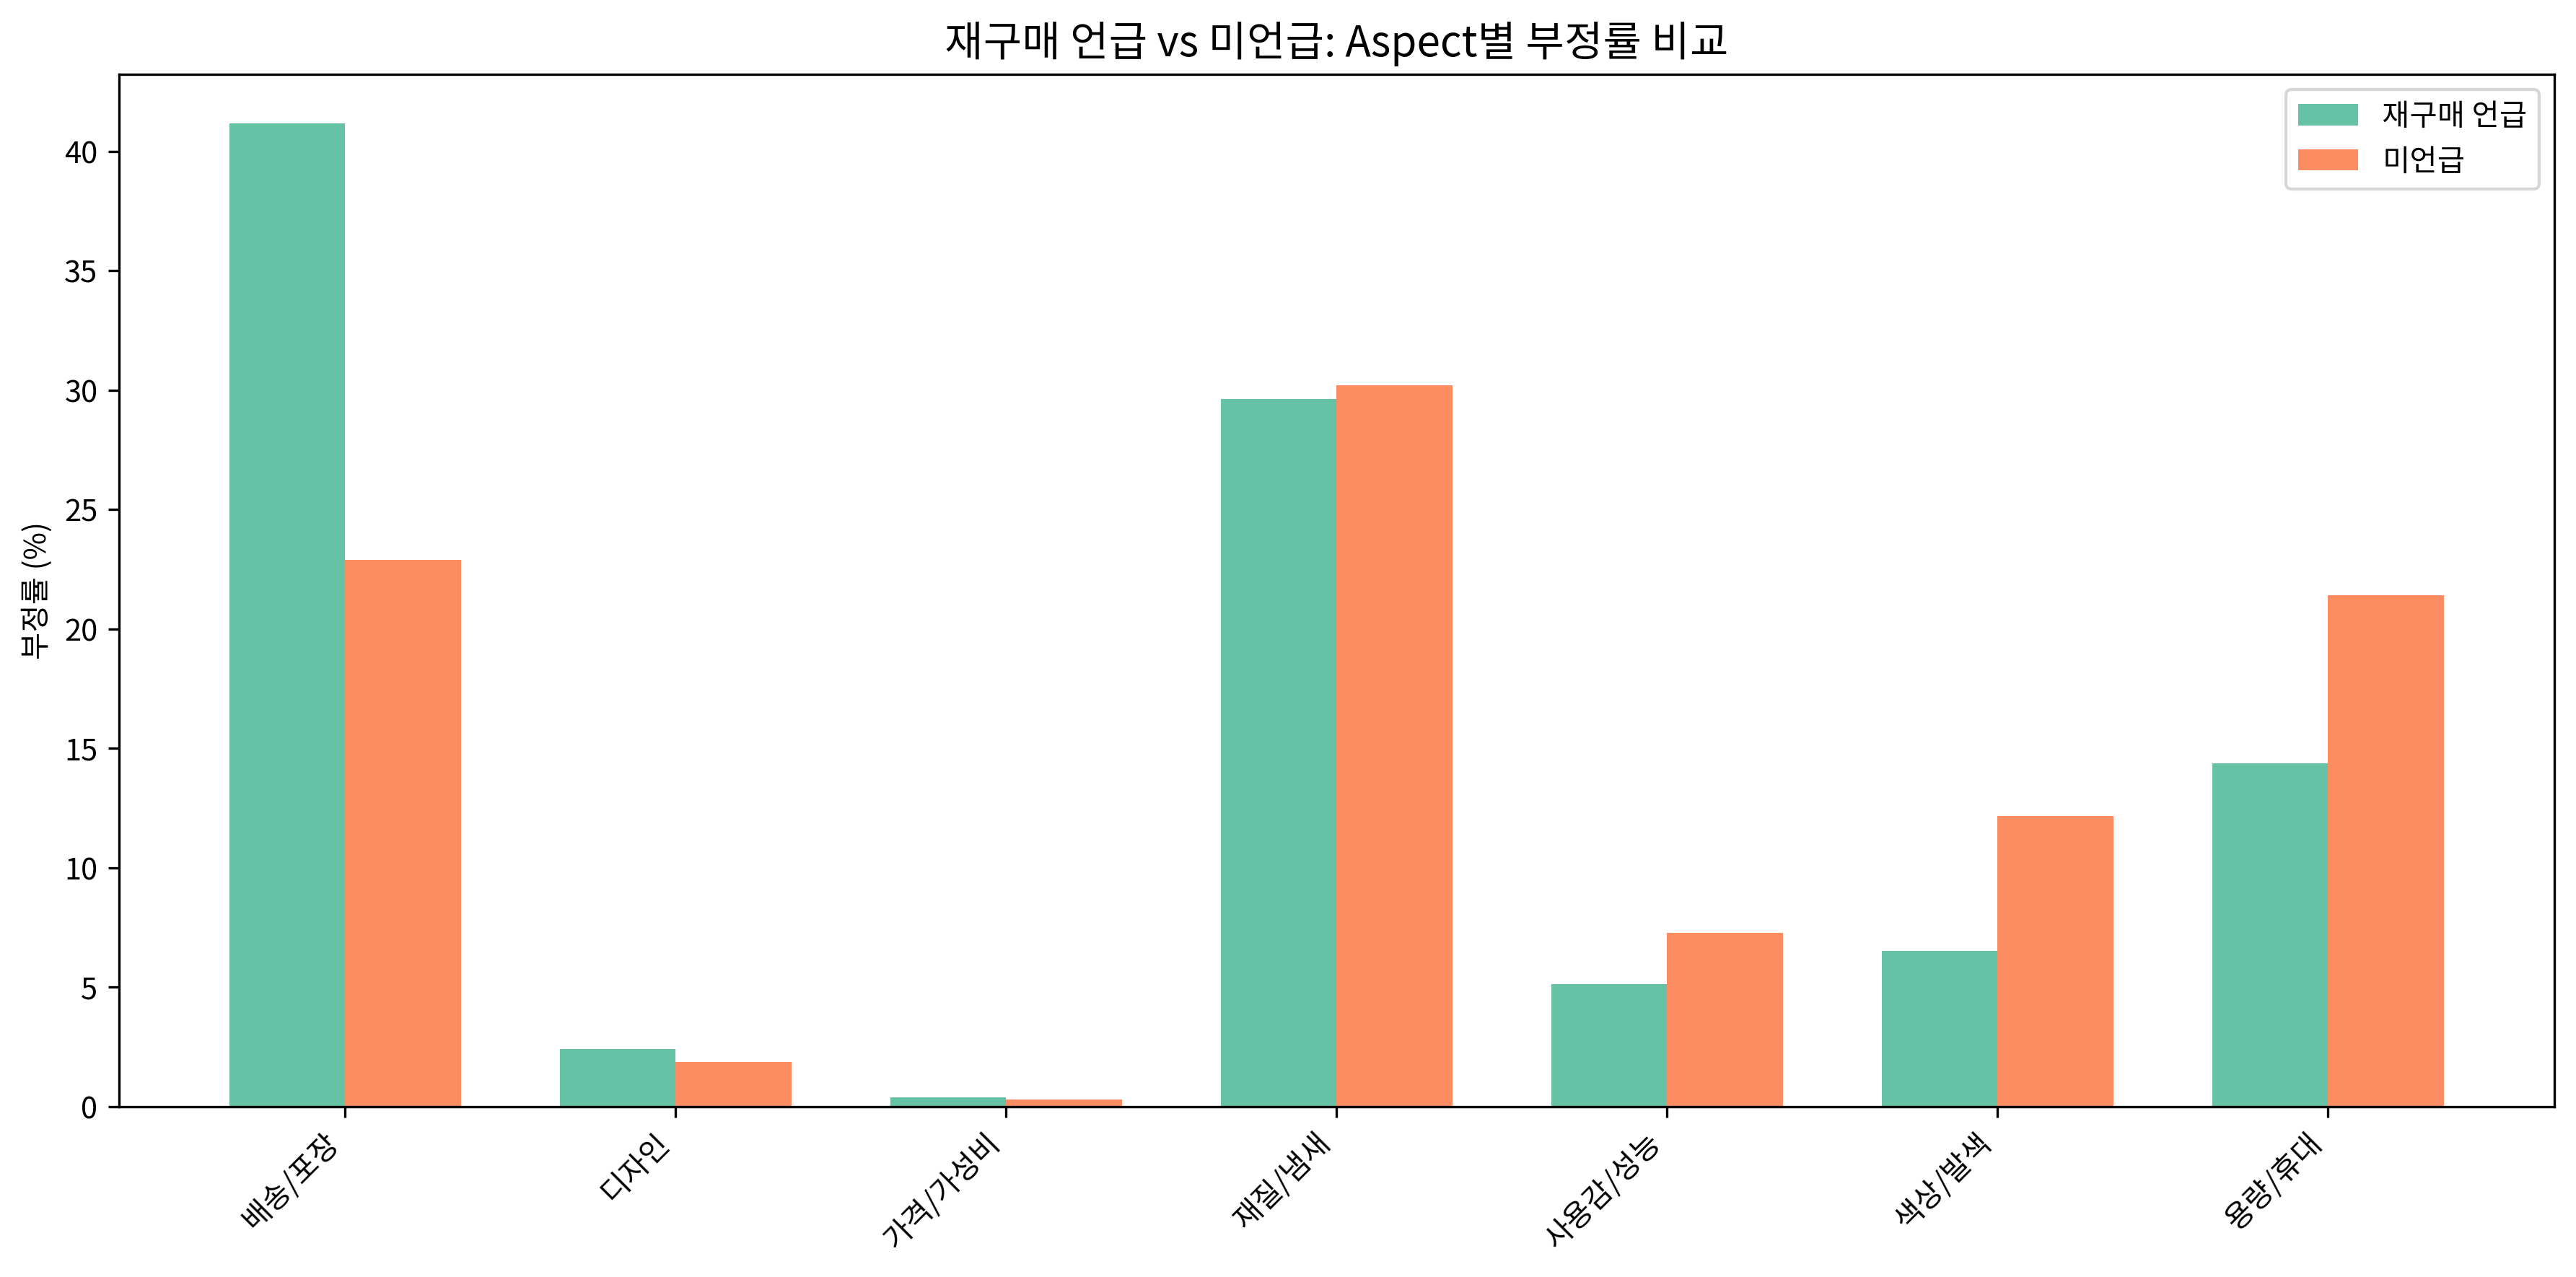

In [14]:
# 부정률 비교
neg_rate = reorder_merged[reorder_merged['aspect_sentiment'] == 'negative'].copy()
neg_pivot = neg_rate.pivot_table(
    index='aspect', columns='has_repurchase', values='rate', fill_value=0)
neg_pivot.columns = ['미언급 부정률', '재구매 언급 부정률']
neg_pivot['차이'] = neg_pivot['재구매 언급 부정률'] - neg_pivot['미언급 부정률']
neg_pivot = neg_pivot.sort_values('차이', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(neg_pivot))
width = 0.35
ax.bar(x - width/2, neg_pivot['재구매 언급 부정률'], width,
       label='재구매 언급', color='#66c2a5')
ax.bar(x + width/2, neg_pivot['미언급 부정률'], width,
       label='미언급', color='#fc8d62')
ax.set_xticks(x)
ax.set_xticklabels(neg_pivot.index, rotation=45, ha='right')
ax.set_title('재구매 언급 vs 미언급: Aspect별 부정률 비교', fontsize=14)
ax.set_ylabel('부정률 (%)')
ax.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/10_재구매_vs_비재구매_부정률.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. 가격대별 분석

In [15]:
# 가격대 구분
bins = [0, 1000, 2000, 3000, 5000]
labels = ['~1,000원', '~2,000원', '~3,000원', '~5,000원']
df_price = df_real.dropna(subset=['price']).copy()
df_price['price_range'] = pd.cut(
    df_price['price'], bins=bins, labels=labels, include_lowest=True)

print("가격대별 분포 (aspect 행 기준):")
print(df_price['price_range'].value_counts().sort_index())

가격대별 분포 (aspect 행 기준):
price_range
~1,000원     17483
~2,000원     13116
~3,000원    127221
~5,000원    131452
Name: count, dtype: int64


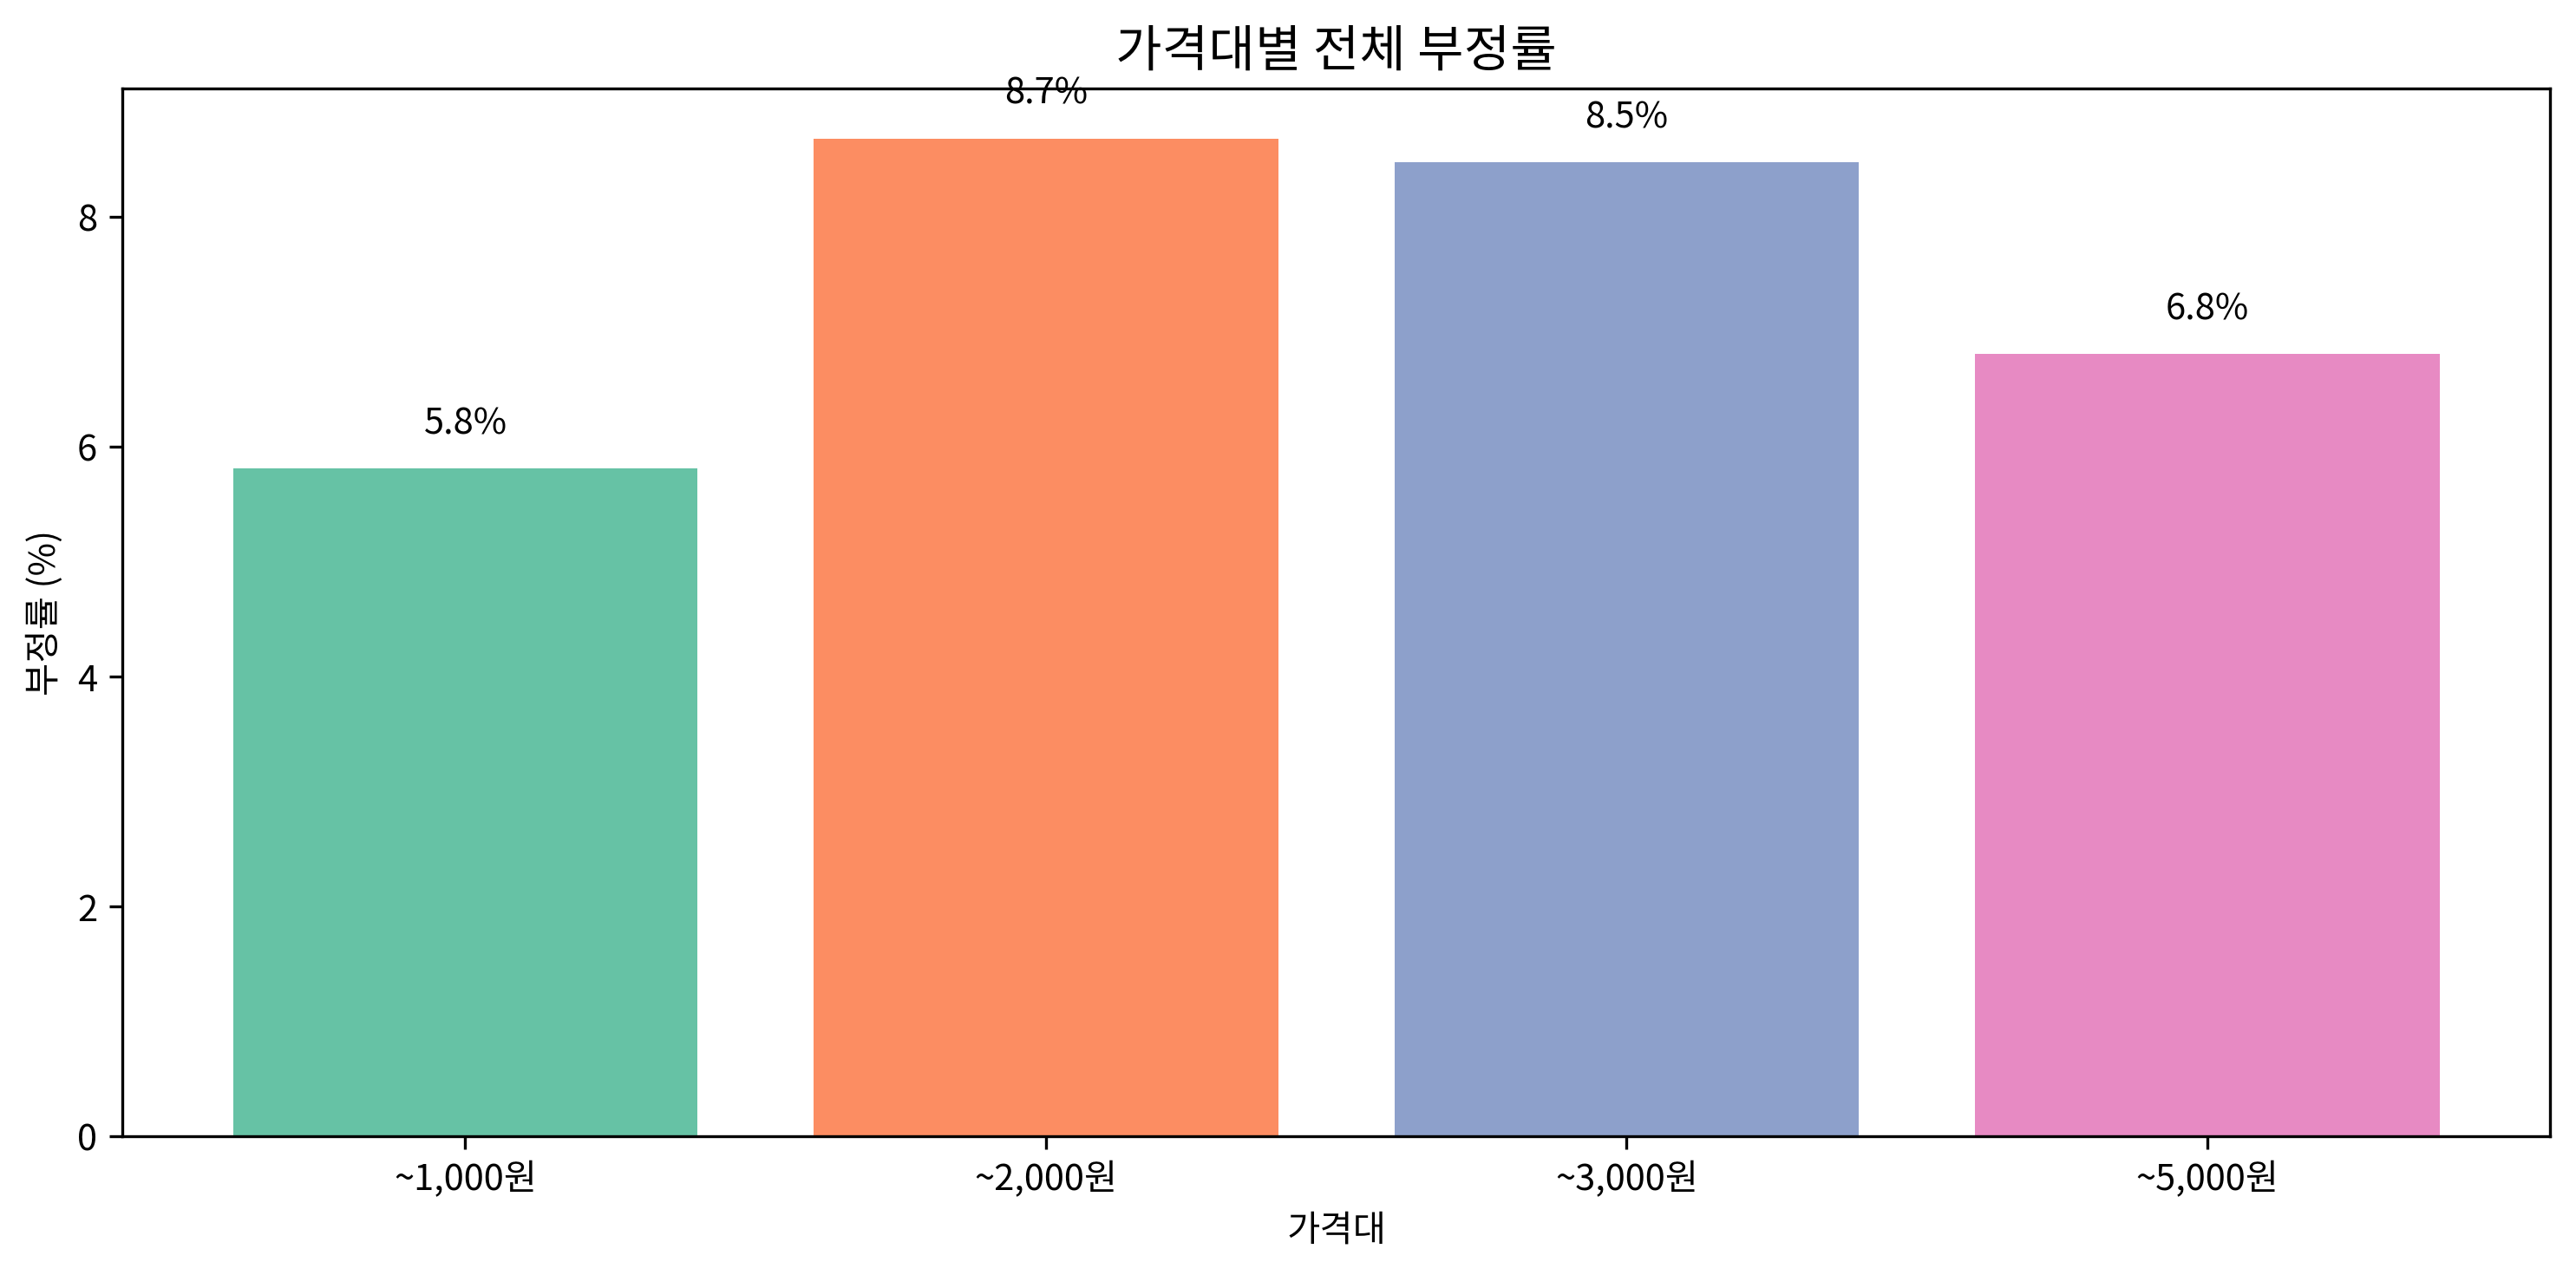

In [16]:
# 가격대별 부정률
price_neg = df_price.groupby('price_range').apply(
    lambda x: (x['aspect_sentiment'] == 'negative').mean() * 100
).reset_index(name='부정률')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(price_neg['price_range'].astype(str), price_neg['부정률'],
       color=sns.color_palette('Set2'))
ax.set_title('가격대별 전체 부정률', fontsize=14)
ax.set_xlabel('가격대')
ax.set_ylabel('부정률 (%)')
for i, v in enumerate(price_neg['부정률']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/11_가격대별_부정률.png', dpi=300, bbox_inches='tight')
plt.show()

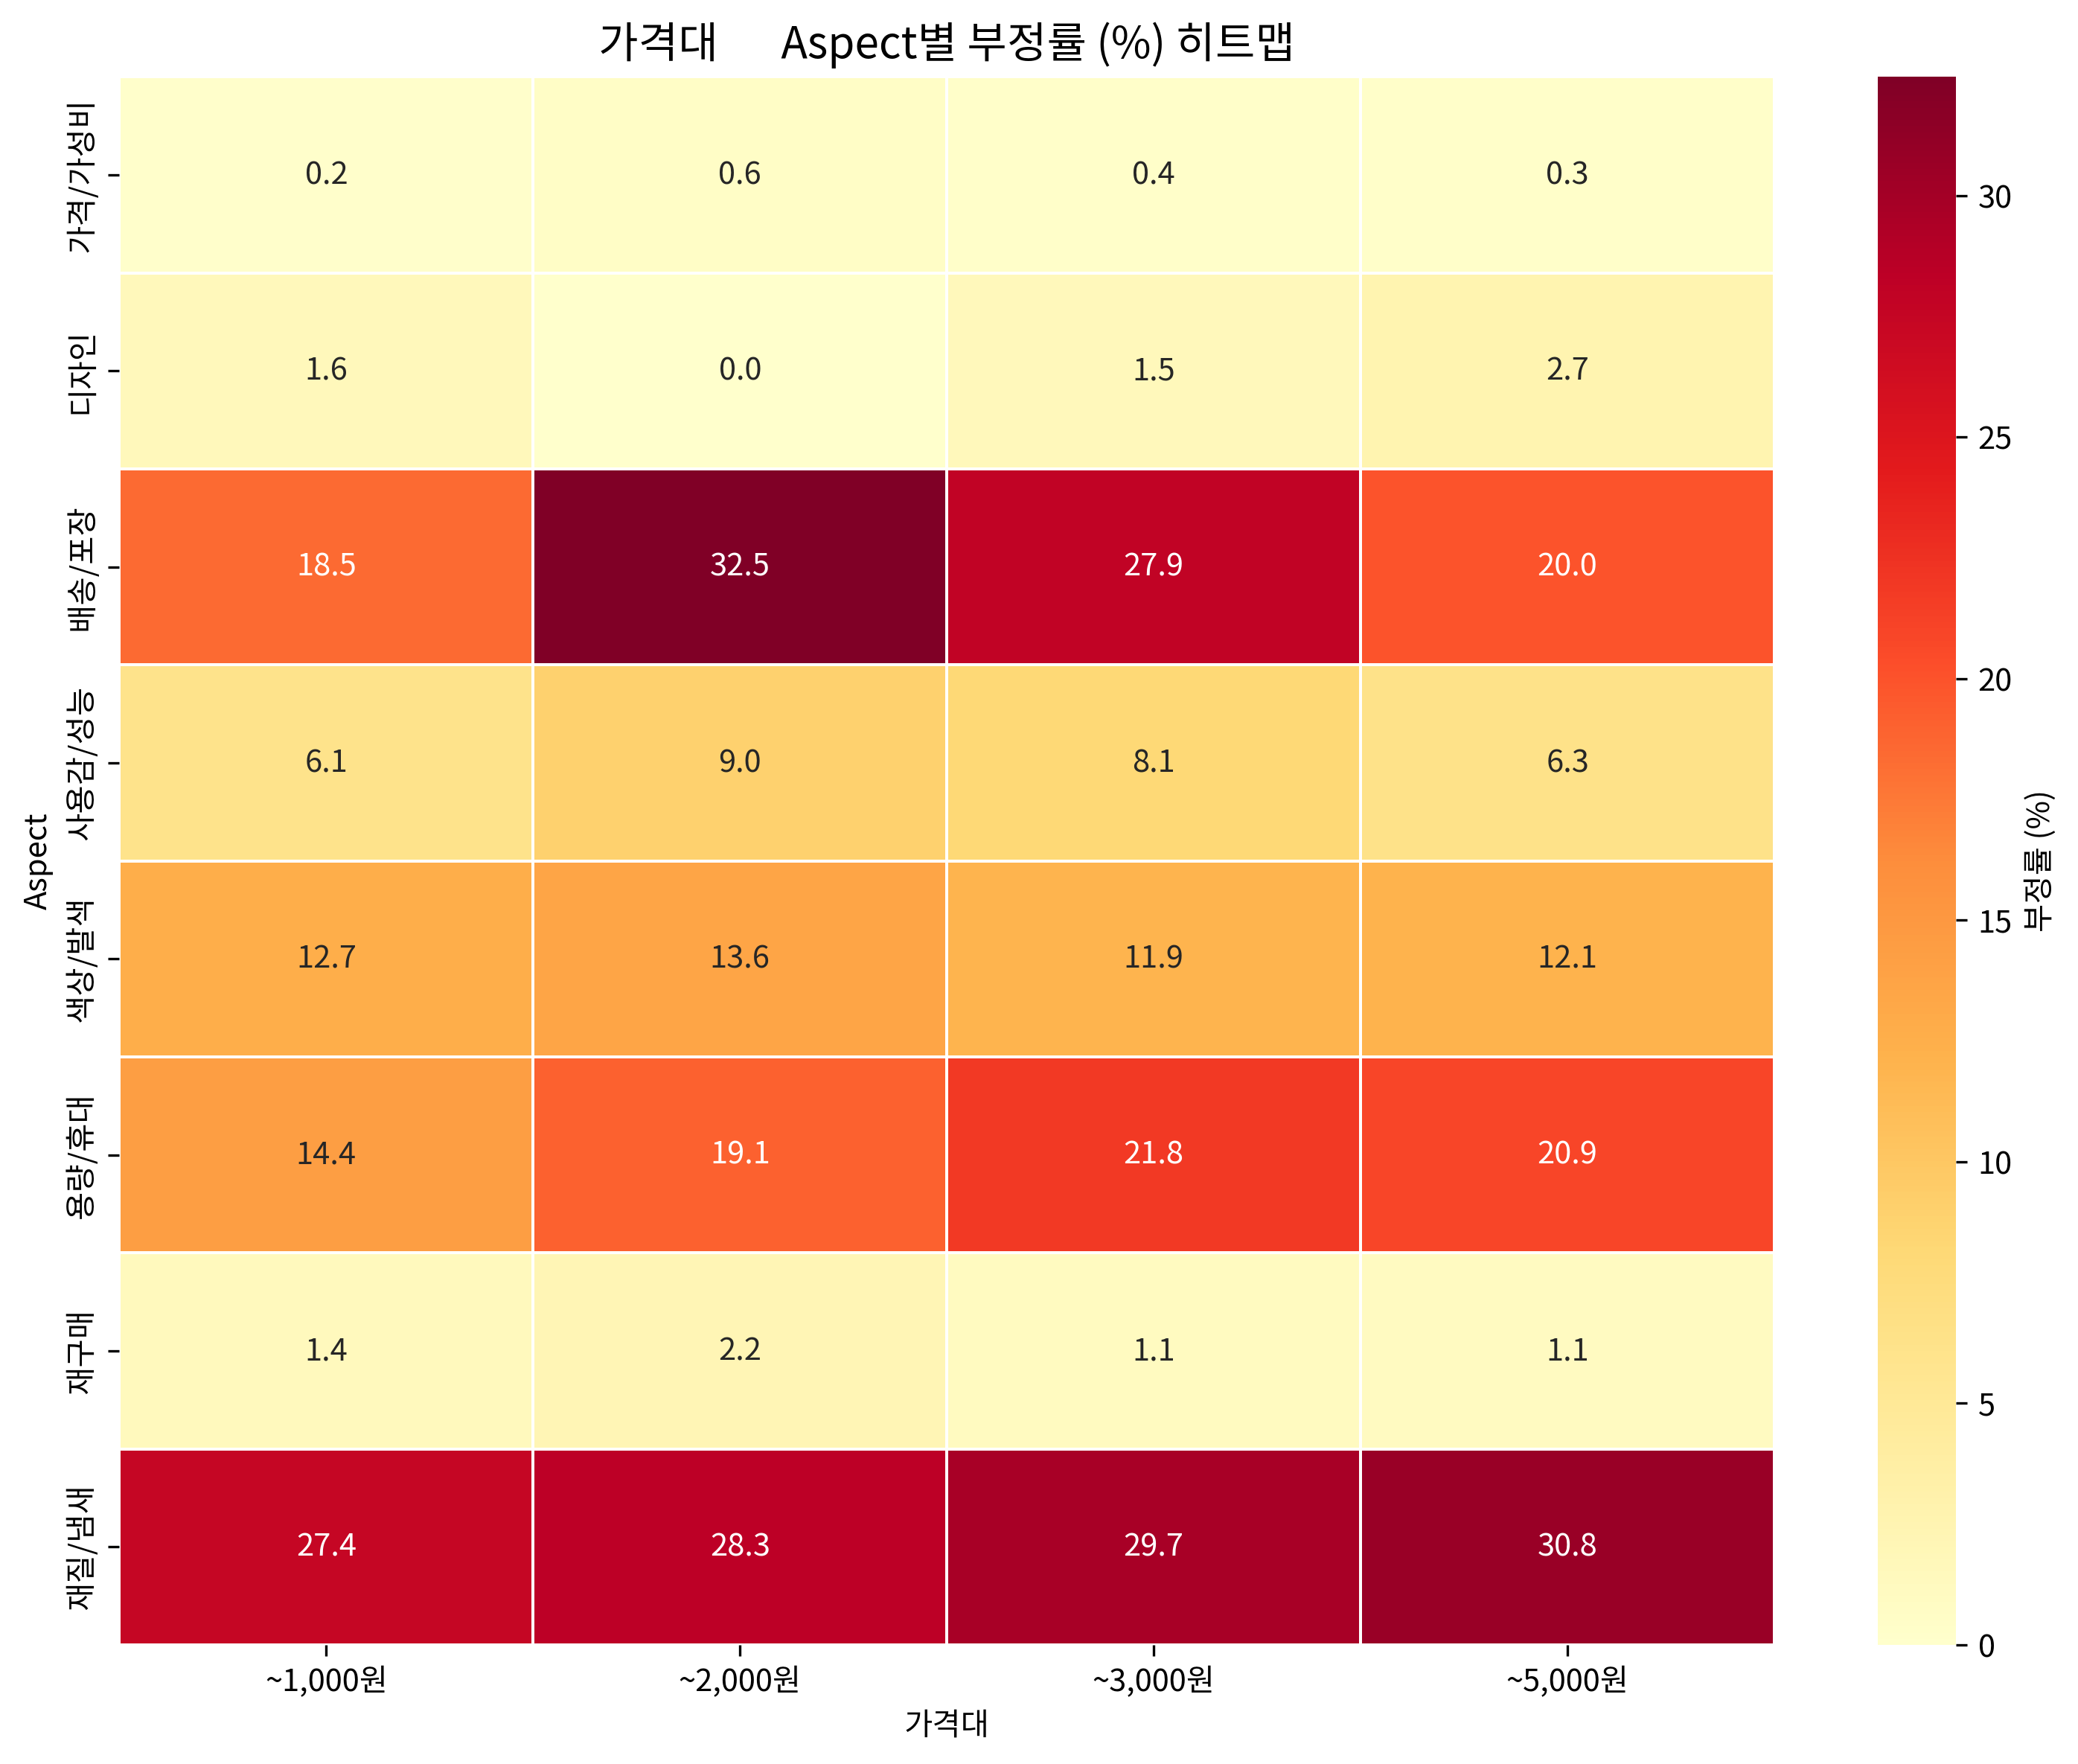

In [17]:
# 가격대별 × Aspect별 부정률 히트맵
price_aspect_neg = df_price.pivot_table(
    index='aspect',
    columns='price_range',
    values='aspect_sentiment',
    aggfunc=lambda x: (x == 'negative').mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(price_aspect_neg, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '부정률 (%)'})
ax.set_title('가격대 × Aspect별 부정률 (%) 히트맵', fontsize=14)
ax.set_ylabel('Aspect')
ax.set_xlabel('가격대')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/12_가격대_Aspect_부정률_히트맵.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. 부정 리뷰 집중 분석 (리스크 진단)

In [18]:
df_negative = df_real[df_real['aspect_sentiment'] == 'negative'].copy()
print(f"전체 부정 건수: {len(df_negative):,} "
      f"({len(df_negative)/len(df_real)*100:.1f}%)")
print(f"부정 리뷰 관련 고유 상품 수: {df_negative['product_code'].nunique():,}")

전체 부정 건수: 21,885 (7.6%)
부정 리뷰 관련 고유 상품 수: 885


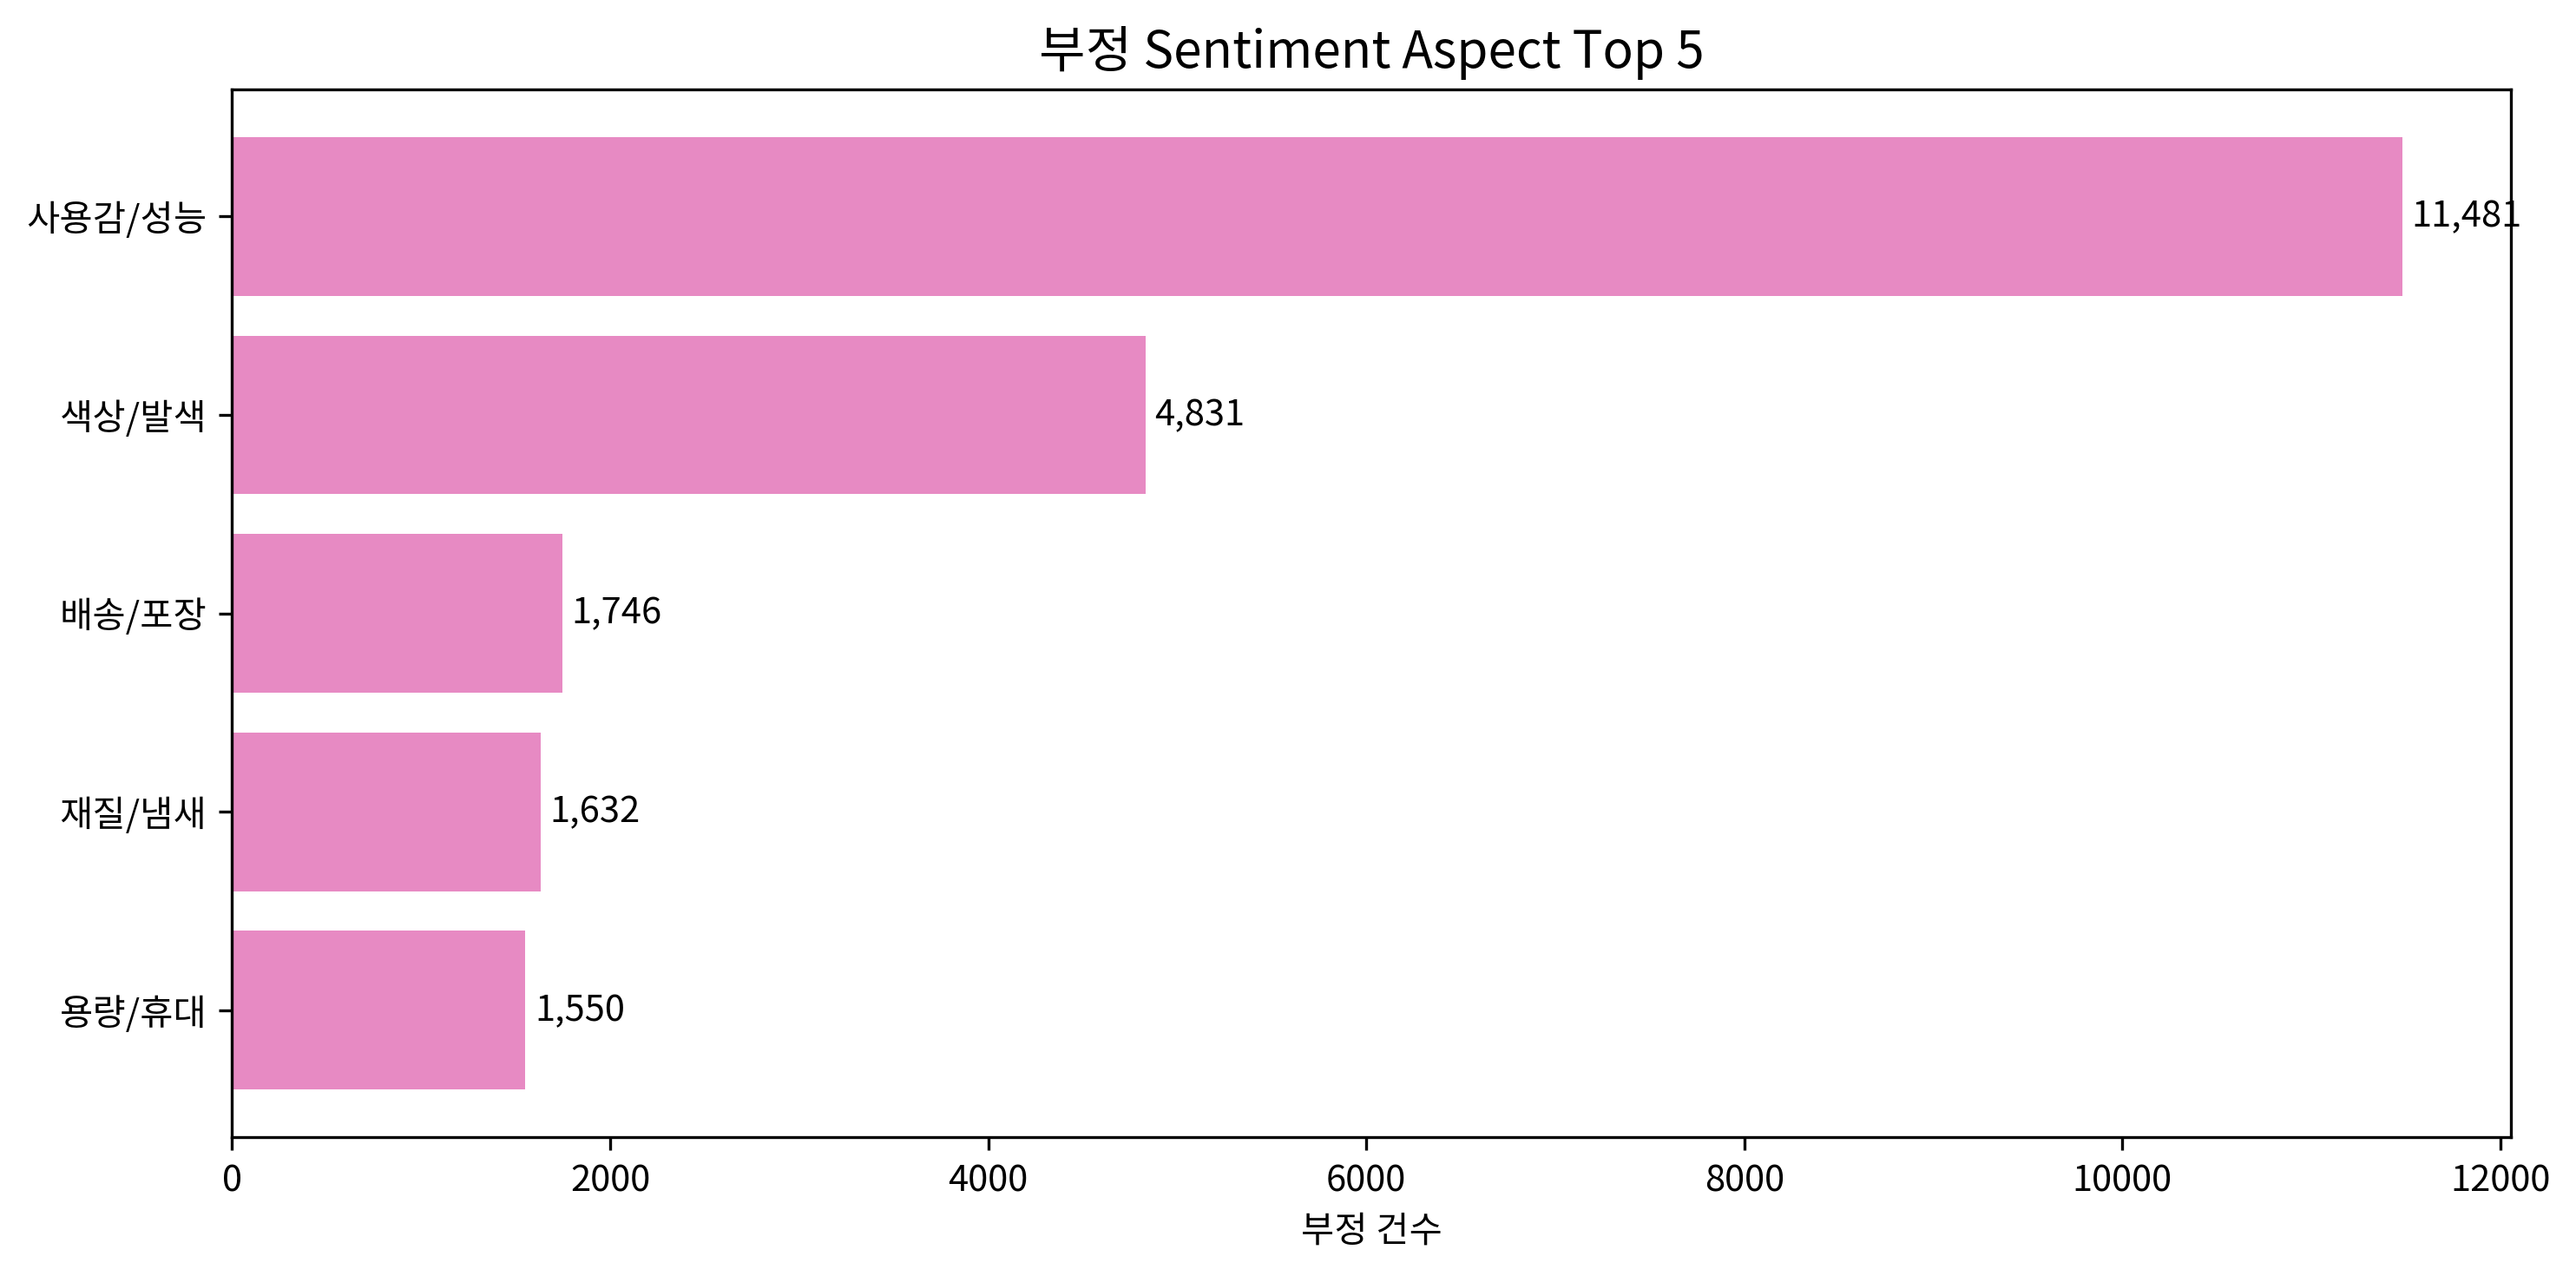

In [19]:
# Aspect별 부정 건수 Top 5
neg_aspect = df_negative['aspect'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
top5 = neg_aspect.head(5)
bars = ax.barh(top5.index[::-1], top5.values[::-1], color='#e78ac3')
ax.set_title('부정 Sentiment Aspect Top 5', fontsize=14)
ax.set_xlabel('부정 건수')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', ha='left', va='center', fontsize=10)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/13_부정_Aspect_Top5.png', dpi=300, bbox_inches='tight')
plt.show()

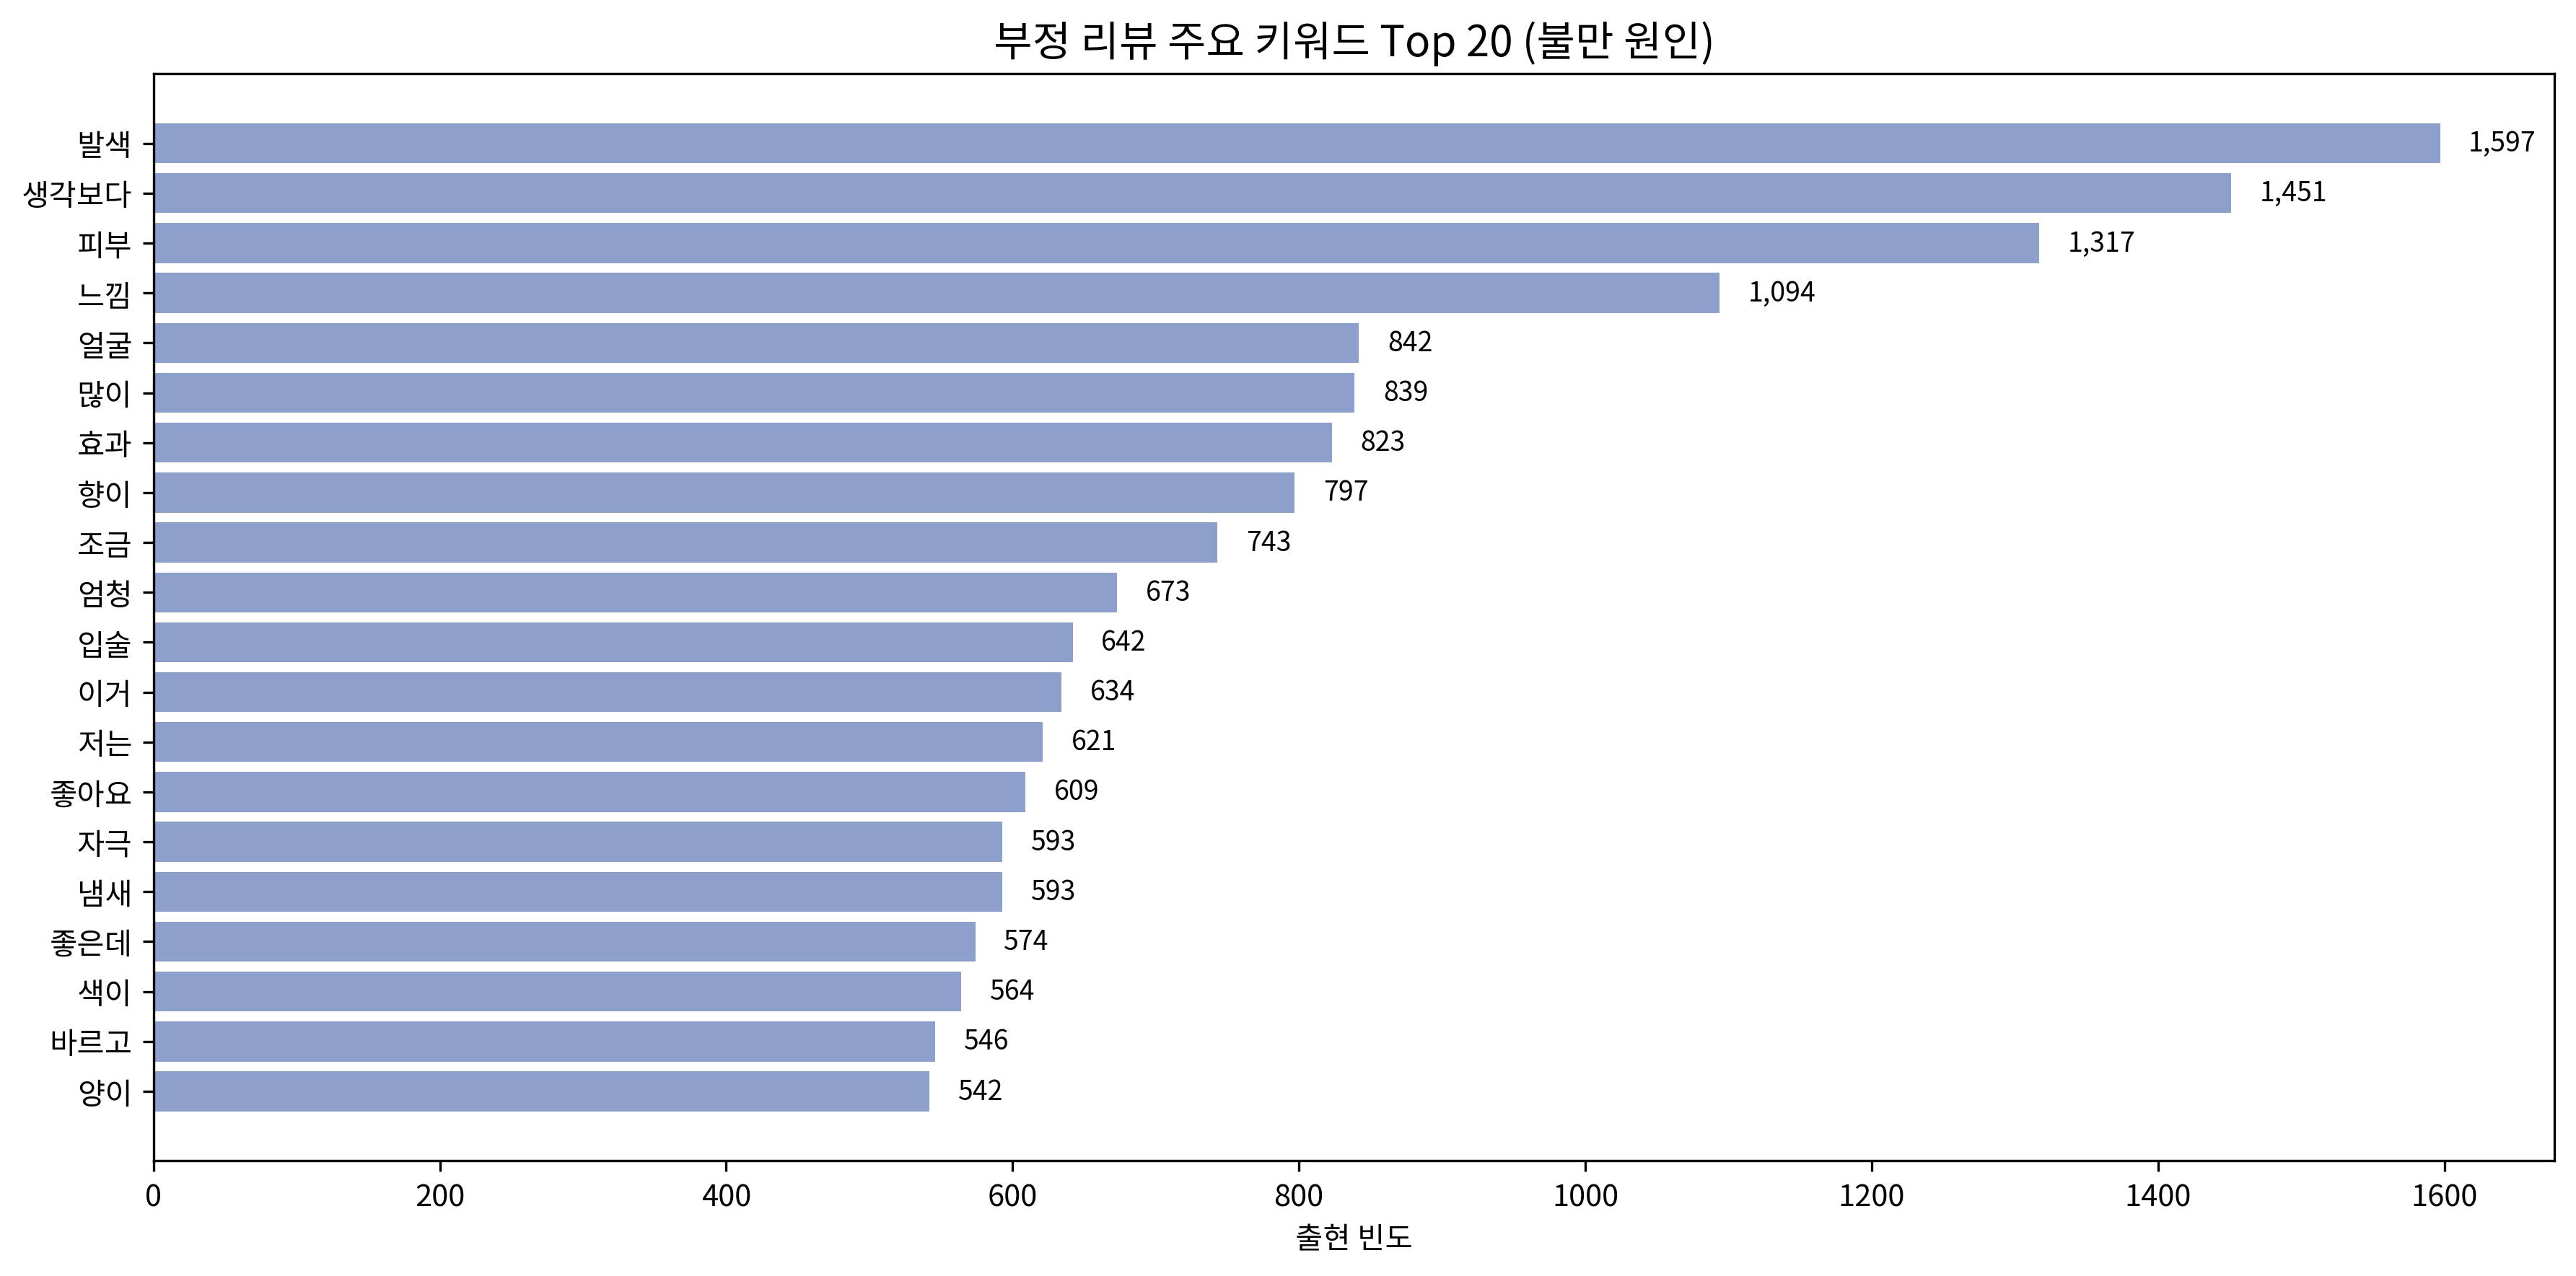

In [20]:
# 부정 리뷰 텍스트 키워드 분석 (원문 기반)
from collections import Counter
import re

# 부정 aspect가 있는 리뷰의 원문
neg_review_ids = df_negative['review_id'].unique()
neg_texts = df_review[df_review['review_id'].isin(neg_review_ids)]['text'].dropna().tolist()

stop_words = {
    '이다', '하다', '것이', '에서', '으로', '해당', '있다', '없다', '대한', '관련',
    '때문', '이라', '라고', '한다', '있는', '없는', '하는', '된다', '이며', '부분',
    '너무', '않다', '않는', '했다', '이고', '같은', '이런', '그냥', '좋은', '나쁜',
    '사용', '제품', '리뷰', '구매', '생각', '정도', '그래서', '하지만', '근데',
    '진짜', '완전', '아주', '매우', '정말', '좀', '약간', '하고', '해서', '인데',
    '같아요', '있어요', '없어요', '했어요', '이에요', '거예요', '는데요', '봤는데',
}

def strip_particle(word):
    particles = ['에서', '으로', '이라는', '에는', '에도',
                 '이', '가', '을', '를', '의', '에', '와', '과', '도', '은', '는']
    for p in particles:
        if word.endswith(p) and len(word) - len(p) >= 2:
            return word[:-len(p)]
    return word

keywords = []
for text in neg_texts:
    words = re.findall(r'[가-힣]{2,}', str(text))
    for w in words:
        w_clean = strip_particle(w)
        if w_clean not in stop_words and len(w_clean) >= 2:
            keywords.append(w_clean)

keyword_counts = Counter(keywords).most_common(20)

fig, ax = plt.subplots(figsize=(12, 6))
words_list = [w for w, c in keyword_counts[::-1]]
counts_list = [c for w, c in keyword_counts[::-1]]
ax.barh(words_list, counts_list, color='#8da0cb')
ax.set_title('부정 리뷰 주요 키워드 Top 20 (불만 원인)', fontsize=14)
ax.set_xlabel('출현 빈도')
for i, (w, c) in enumerate(keyword_counts[::-1]):
    ax.text(c + 20, i, f'{c:,}', va='center', fontsize=9)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/14_부정_키워드_Top20.png', dpi=300, bbox_inches='tight')
plt.show()

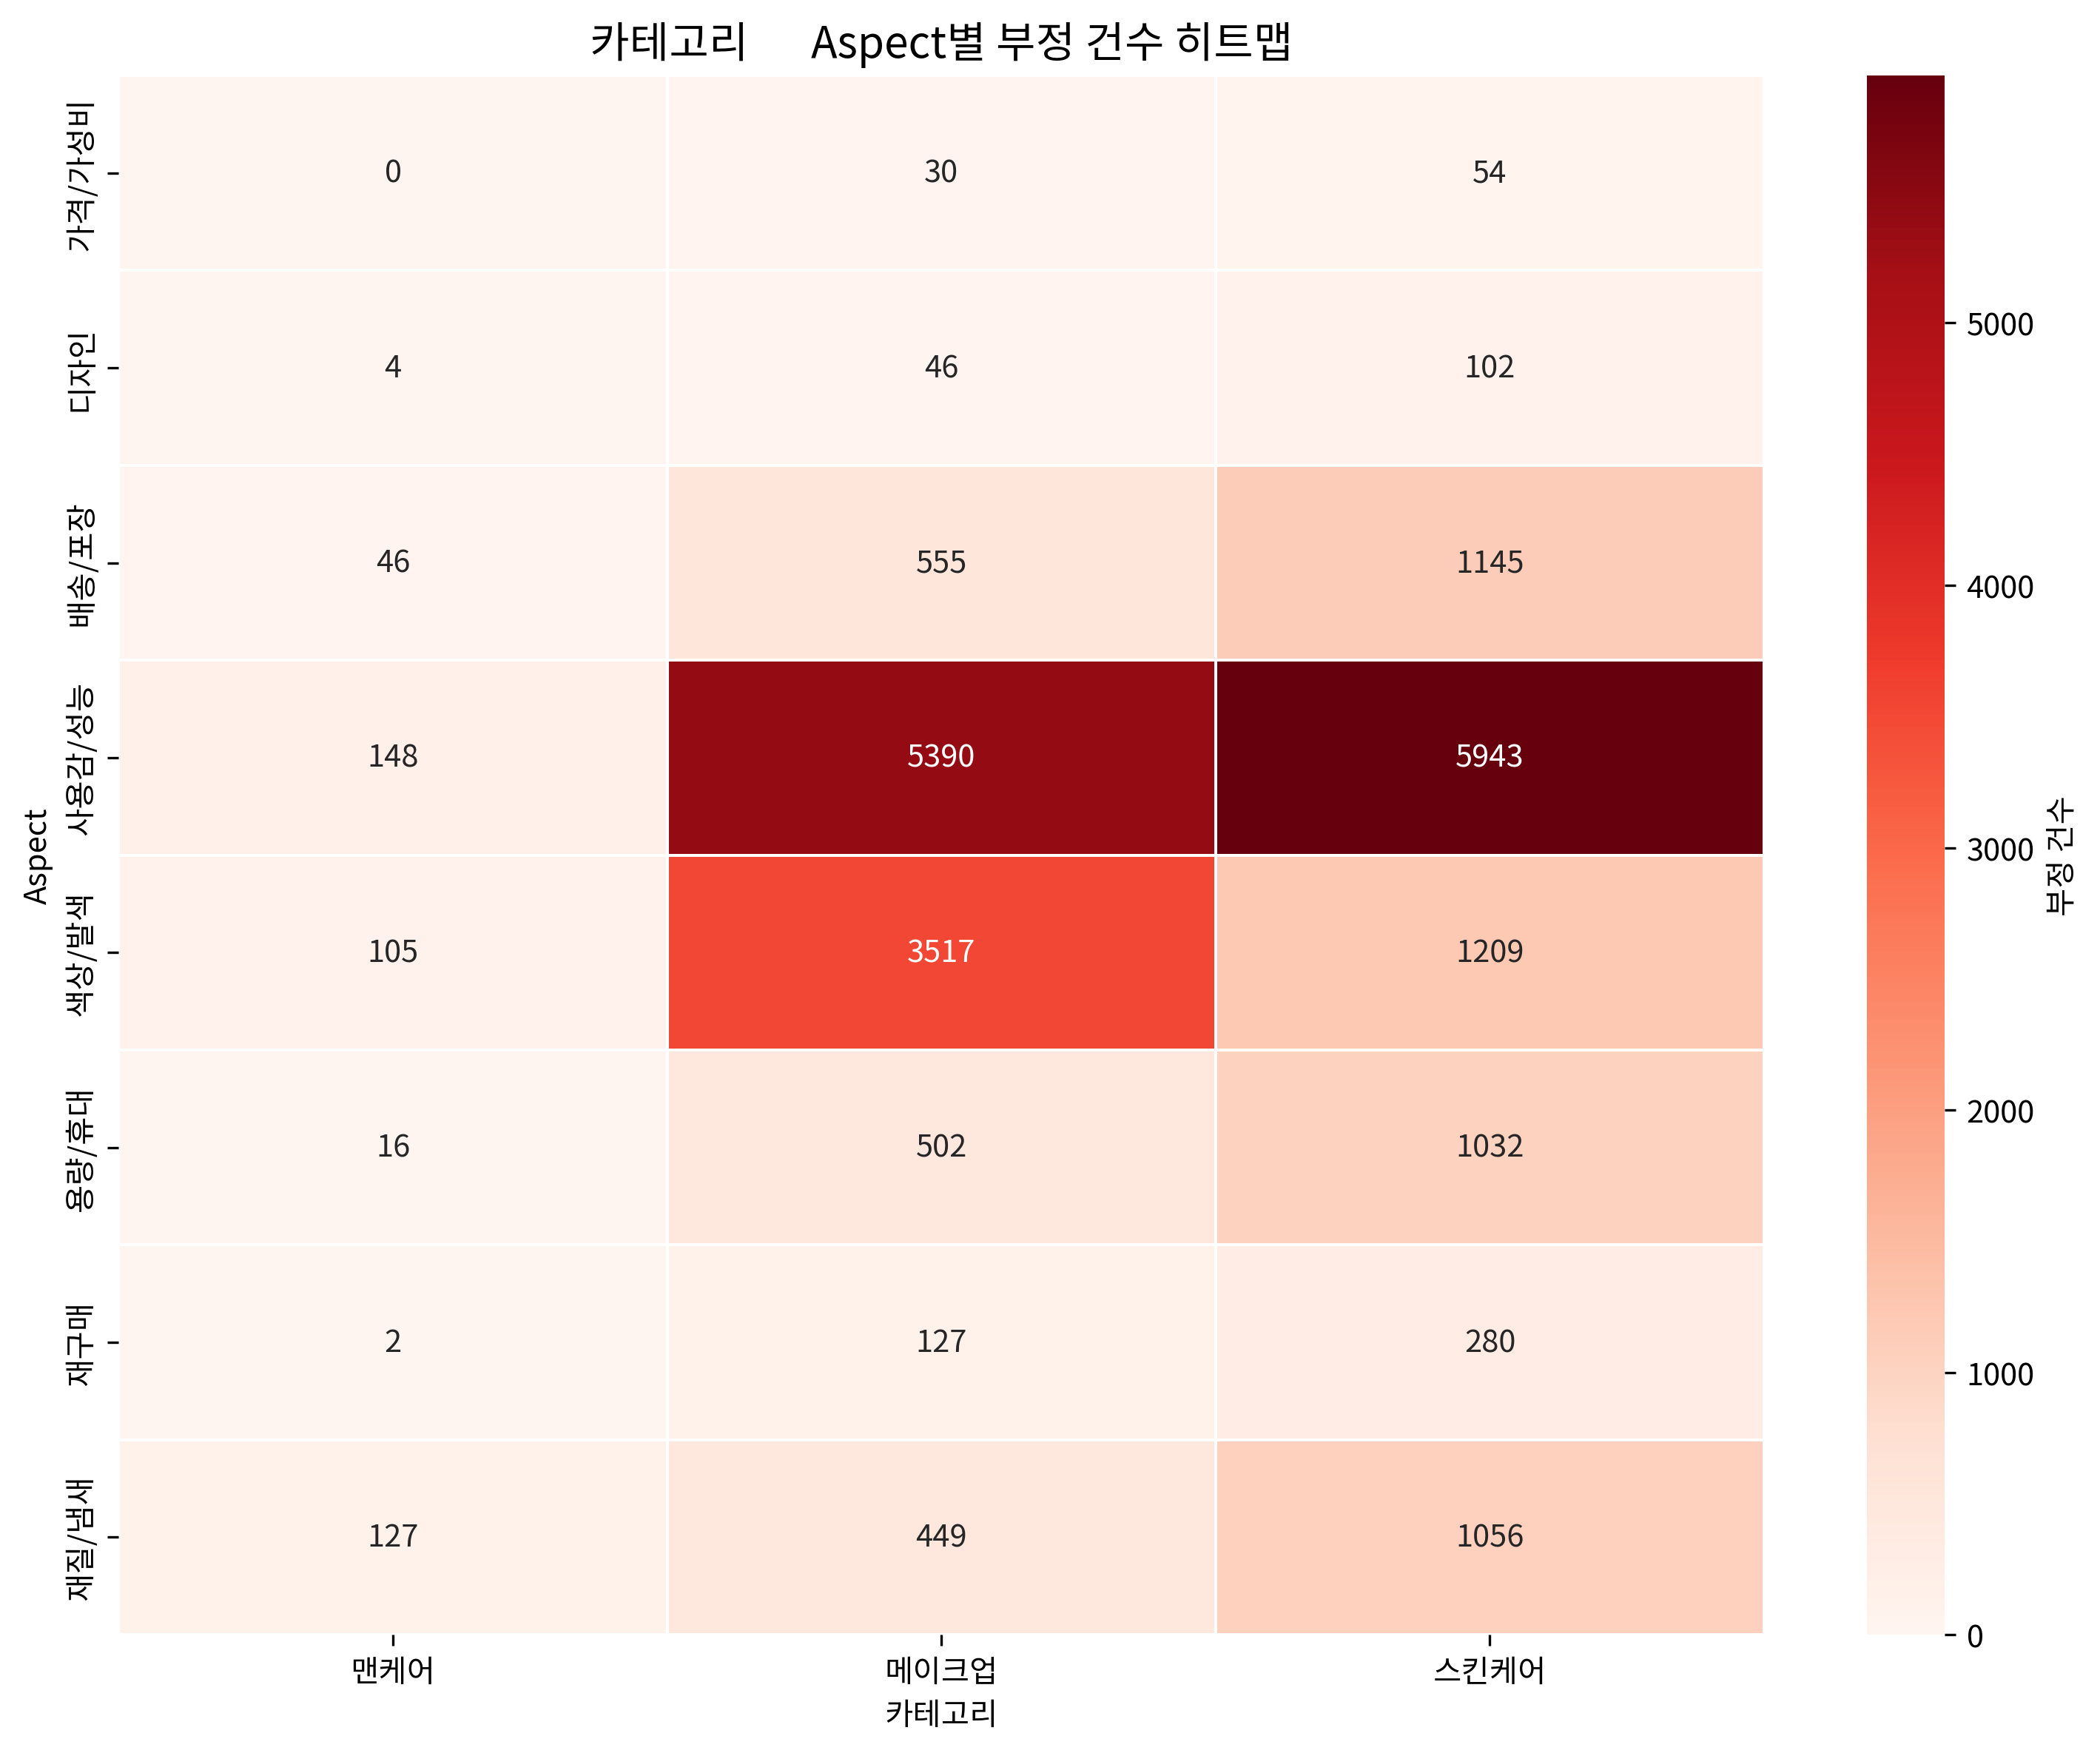

In [21]:
# 카테고리 × Aspect별 부정 히트맵
df_neg_cat = df_negative.dropna(subset=['category_1'])
neg_cross = pd.crosstab(df_neg_cat['aspect'], df_neg_cat['category_1'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(neg_cross, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': '부정 건수'})
ax.set_title('카테고리 × Aspect별 부정 건수 히트맵', fontsize=14)
ax.set_ylabel('Aspect')
ax.set_xlabel('카테고리')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/15_카테고리_Aspect_부정_히트맵.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. 상품별 Sentiment 순위

In [22]:
# 리뷰 30건 이상 상품 필터링 (323K 스케일 기준)
MIN_REVIEWS = 30
product_counts = df_real.groupby('product_code')['review_id'].nunique()
valid_products = product_counts[product_counts >= MIN_REVIEWS].index
df_valid = df_real[df_real['product_code'].isin(valid_products)].copy()

print(f"리뷰 {MIN_REVIEWS}건 이상 상품: {len(valid_products):,}개 "
      f"(전체 {n_products:,}개 중)")
print(f"해당 상품 데이터: {len(df_valid):,}행")

리뷰 30건 이상 상품: 829개 (전체 937개 중)
해당 상품 데이터: 286,830행


In [23]:
# 긍정률 / 부정률 계산
product_sent = df_valid.groupby(['product_code', 'product_name']).apply(
    lambda x: pd.Series({
        '긍정률': (x['aspect_sentiment'] == 'positive').mean() * 100,
        '부정률': (x['aspect_sentiment'] == 'negative').mean() * 100,
        '건수': x['review_id'].nunique()
    })
).reset_index()

# 긍정률 Top 10
top10_pos = product_sent.nlargest(10, '긍정률')
print("긍정률 Top 10 상품:")
print("=" * 80)
for _, r in top10_pos.iterrows():
    print(f"  {r['product_name'][:35]:<38} "
          f"긍정률: {r['긍정률']:.1f}%  (리뷰: {int(r['건수'])}건)")

print()

# 부정률 Top 10 (리스크 상품)
top10_neg = product_sent.nlargest(10, '부정률')
print("부정률 Top 10 상품 (리스크 상품):")
print("=" * 80)
for _, r in top10_neg.iterrows():
    print(f"  {r['product_name'][:35]:<38} "
          f"부정률: {r['부정률']:.1f}%  (리뷰: {int(r['건수'])}건)")

긍정률 Top 10 상품:
  도루코TG2플러스5P                            긍정률: 98.7%  (리뷰: 65건)
  온더바디 더 내추럴 레몬 산뜻한 클렌징 폼 120g           긍정률: 98.0%  (리뷰: 42건)
  메디필 락토 모공 리프팅 패드 2.0 리필 (190ml/70매)    긍정률: 97.8%  (리뷰: 39건)
  더랩바이블랑두 클리어히알옴므 선크림 35 ml              긍정률: 97.3%  (리뷰: 81건)
  더랩바이블랑두 클리어히알옴므 클렌징폼 120 ml            긍정률: 95.2%  (리뷰: 80건)
  도루코윈4 시스템 면도기 리필형 4P                   긍정률: 94.1%  (리뷰: 62건)
  포인트 라이스 반죽광채 팩클렌저 100g                 긍정률: 94.1%  (리뷰: 138건)
  바세린 진정 시트 마스크팩 23 ml 1매                긍정률: 93.9%  (리뷰: 49건)
  제이엠솔루션 아크클리어 클렌징폼 150 ml               긍정률: 93.3%  (리뷰: 37건)
  도루코윈4 시스템 면도기 SET                      긍정률: 93.0%  (리뷰: 52건)

부정률 Top 10 상품 (리스크 상품):
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 페어리핑크        부정률: 44.1%  (리뷰: 65건)
  태그 톤업선파우더(1호_페일라이트) 5 g                부정률: 38.6%  (리뷰: 39건)
  NEW 스타일리쉬 오토 아이라이너 펜슬 블랙               부정률: 36.8%  (리뷰: 34건)
  프롬더스킨 아웃도어 선젤패치 10 ml                  부정률: 35.8%  (리뷰: 86건)
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 듀이골드         부정률: 35.0%  (리뷰: 65건)
  [01 그레이브라운] 

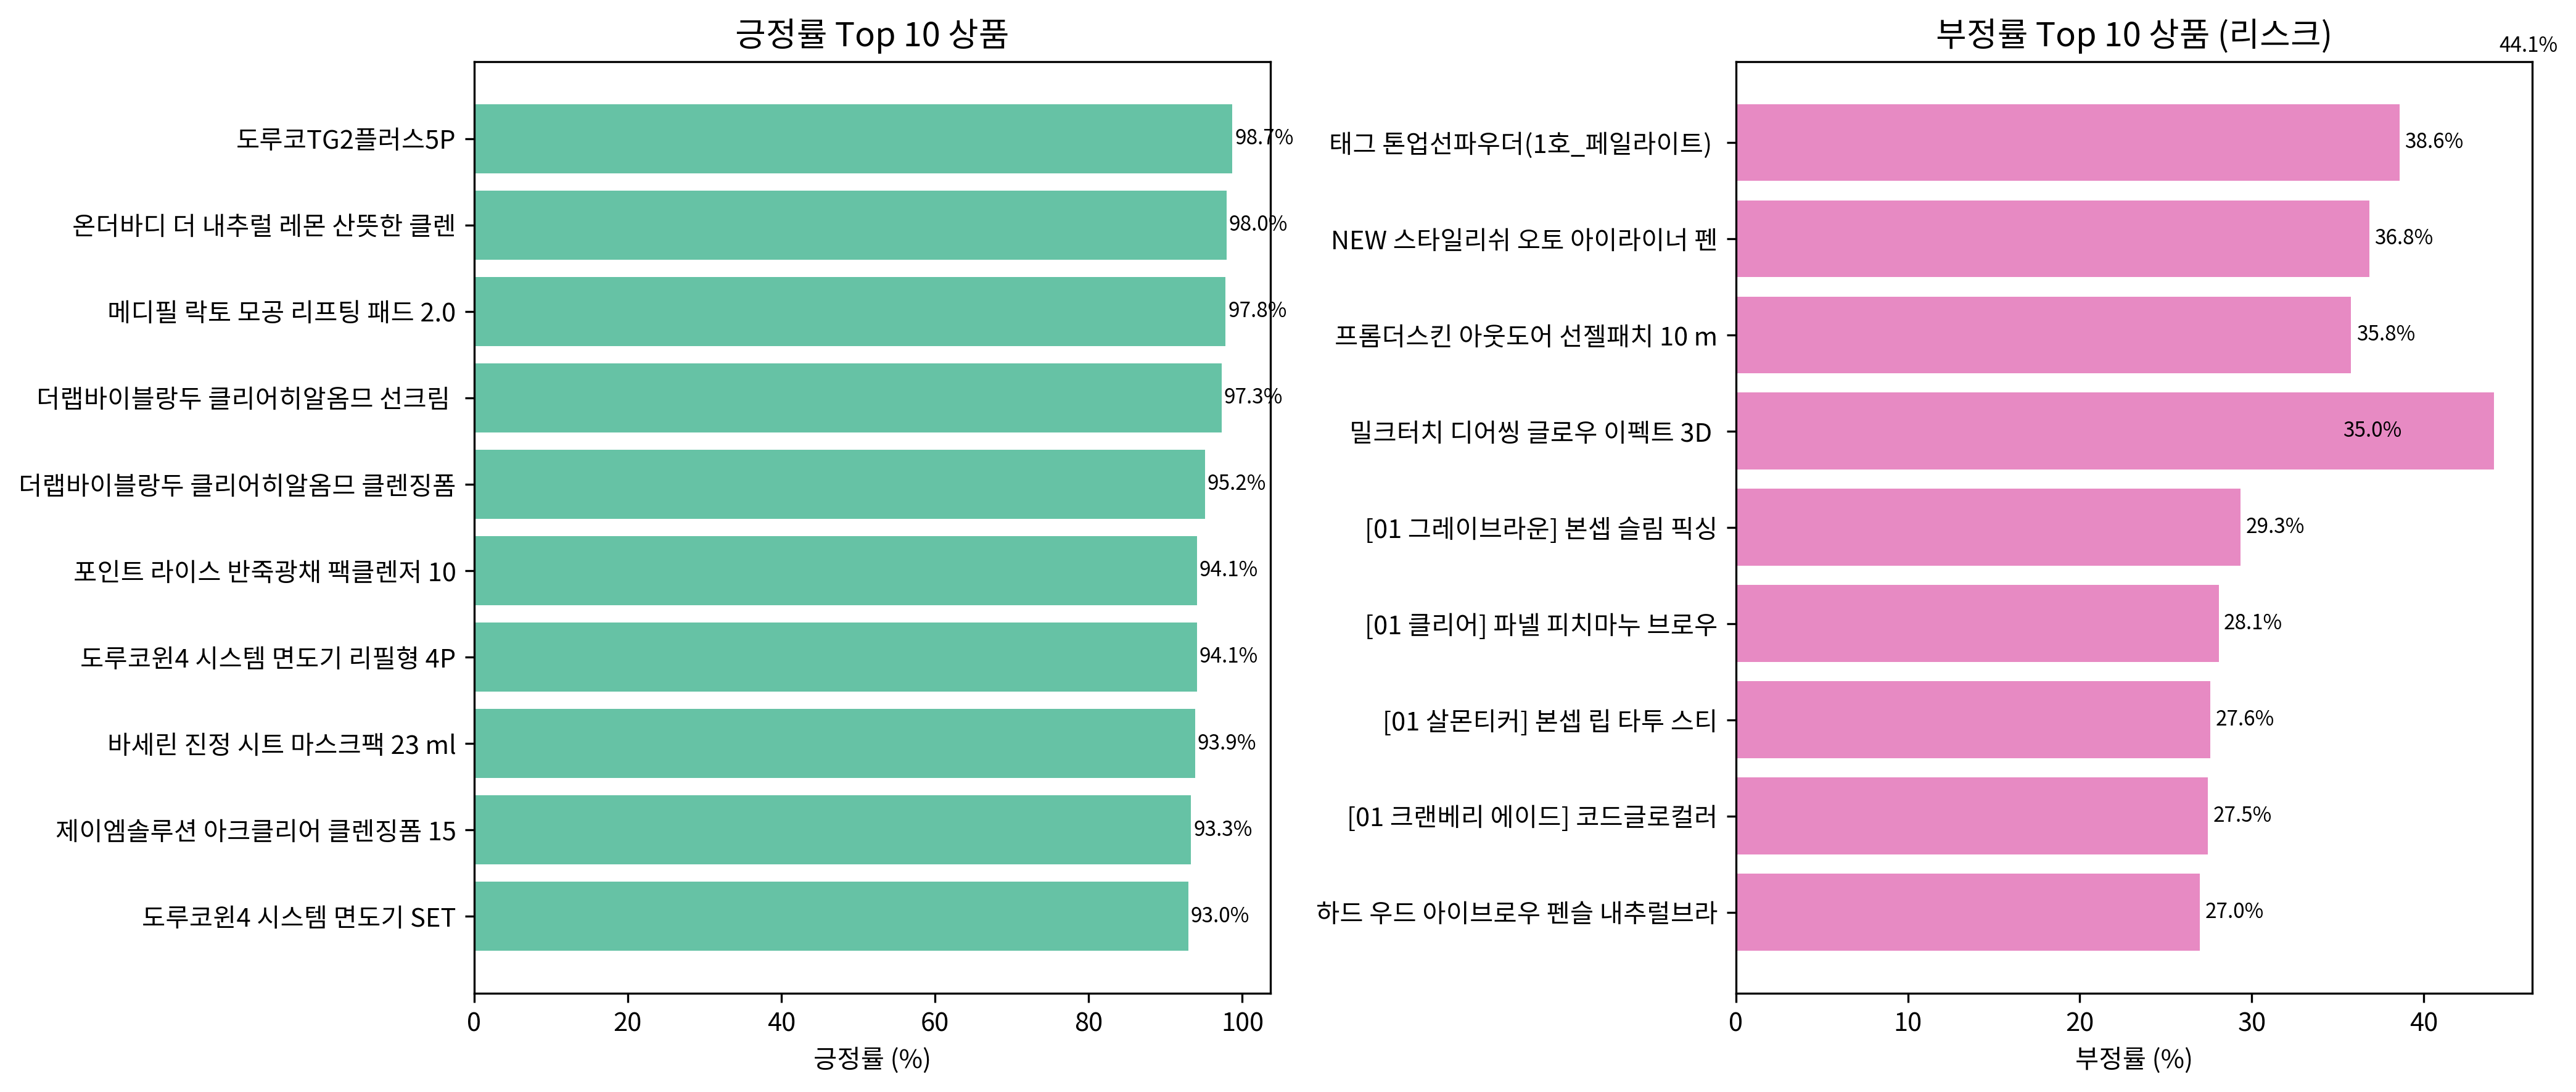

In [24]:
# 시각화: Top 10 / Bottom 10
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 긍정률 Top 10
top10_pos_sorted = top10_pos.sort_values('긍정률', ascending=True)
labels_pos = [n[:20] for n in top10_pos_sorted['product_name']]
axes[0].barh(labels_pos, top10_pos_sorted['긍정률'], color='#66c2a5')
axes[0].set_title('긍정률 Top 10 상품', fontsize=13)
axes[0].set_xlabel('긍정률 (%)')
for i, v in enumerate(top10_pos_sorted['긍정률']):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

# 부정률 Top 10
top10_neg_sorted = top10_neg.sort_values('부정률', ascending=True)
labels_neg = [n[:20] for n in top10_neg_sorted['product_name']]
axes[1].barh(labels_neg, top10_neg_sorted['부정률'], color='#e78ac3')
axes[1].set_title('부정률 Top 10 상품 (리스크)', fontsize=13)
axes[1].set_xlabel('부정률 (%)')
for i, v in enumerate(top10_neg_sorted['부정률']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(f'{FIG_DIR}/16_긍정률_부정률_Top10_상품.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# 부정률 높은 상품의 주요 불만 Aspect
risk_products = top10_neg['product_code'].tolist()
df_risk = df_valid[
    (df_valid['product_code'].isin(risk_products)) &
    (df_valid['aspect_sentiment'] == 'negative')]

risk_aspect = df_risk.groupby(
    ['product_name', 'aspect']).size().reset_index(name='count')
risk_top = risk_aspect.sort_values(
    ['product_name', 'count'], ascending=[True, False]).groupby('product_name').head(3)

print("부정률 Top 10 상품의 주요 불만 Aspect:")
print("=" * 80)
for name in risk_top['product_name'].unique():
    subset = risk_top[risk_top['product_name'] == name]
    aspects = ', '.join(
        [f"{r['aspect']}({r['count']:,})" for _, r in subset.iterrows()])
    print(f"  {name[:40]}")
    print(f"    → {aspects}")

부정률 Top 10 상품의 주요 불만 Aspect:
  NEW 스타일리쉬 오토 아이라이너 펜슬 블랙
    → 사용감/성능(8), 색상/발색(4), 배송/포장(1)
  [01 그레이브라운] 본셉 슬림 픽싱 브로우카라
    → 색상/발색(11), 사용감/성능(10), 용량/휴대(1)
  [01 살몬티커] 본셉 립 타투 스티커
    → 사용감/성능(71), 색상/발색(45), 용량/휴대(9)
  [01 크랜베리 에이드] 코드글로컬러 프루티 볼륨 립글로스
    → 색상/발색(7), 사용감/성능(6), 용량/휴대(1)
  [01 클리어] 파넬 피치마누 브로우 래쉬세럼 쉐이퍼
    → 사용감/성능(13), 색상/발색(2), 재질/냄새(1)
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 듀이골드
    → 배송/포장(26), 사용감/성능(4), 가격/가성비(2)
  밀크터치 디어씽 글로우 이펙트 3D 하이라이터 페어리핑크
    → 배송/포장(33), 사용감/성능(5), 색상/발색(2)
  태그 톤업선파우더(1호_페일라이트) 5 g
    → 사용감/성능(12), 색상/발색(7), 배송/포장(1)
  프롬더스킨 아웃도어 선젤패치 10 ml
    → 사용감/성능(19), 색상/발색(9), 용량/휴대(8)
  하드 우드 아이브로우 펜슬 내추럴브라운
    → 색상/발색(10), 사용감/성능(7)
